# Scenario metrics report

Derive RCA, remediation and holistic performance metrics for **online-boutique, sock-shop, and teastore** from existing grade JSON and local run archives. No judge, cluster access or regrading is needed; source files are never changed. Every report table identifies the application.

**Definitions**
- A “good” output for **timing** means the highest scored output in that scenario run, even if its score is below the success threshold. Ties use the earliest `completed_at`.
- Time is **completion time − recorded chaos start**, in seconds/minutes. Missing timestamps remain unknown. Only outputs completed inside recorded chaos intervals contribute to scores, counts and timing; before/after outputs and missing completion times are excluded.
- A **successful session** has score **strictly greater than** the configured threshold (default 0.8). Both succeeded and failed lifecycle jobs can have valid semantic scores. Remediation scores include penalties.
- Differences are **window − baseline**; negative values mean a decrease. Relative change is `100 × (window / baseline − 1)`. Zero baselines have an absolute difference but no percentage change.
- “Improved holistic performance” here means **within the chosen tolerance**, not necessarily an actual improvement: P95 change **< 20%**, with mean 5xx **≤ 0.5 requests/s** by default. The best-window flag measures whether a favorable covered period exists; it does not establish sustained recovery.

**Repeated scenarios:** selection happens independently within each application. By default, select the latest completed attempt for each scenario; when none completed, retain its latest failed/incomplete attempt. The audit table retains every attempt. Set `repeat_policy="all_runs"` to count each run separately. Selection is by completion/time, never by score.

In [1]:
from dataclasses import replace
from pathlib import Path
import sys
import pandas as pd
from IPython.display import display, Markdown

# Works from eda/, Grader/, or the monorepo root.
def find_grader_root():
    for parent in [Path.cwd(), *Path.cwd().parents]:
        for candidate in [parent, parent / "EvaluationPlatform" / "Grader"]:
            if (candidate / "grader" / "pipeline.py").is_file():
                return candidate.resolve()
    raise FileNotFoundError("Run the notebook from this repository or set GRADER_ROOT manually.")

GRADER_ROOT = find_grader_root()
if str(GRADER_ROOT) not in sys.path:
    sys.path.insert(0, str(GRADER_ROOT))
from eda.report import display_source_path
# Refresh the helper when rerunning an already-open notebook kernel.
import importlib
import eda.report_metrics as report_metrics
report_metrics = importlib.reload(report_metrics)
ReportConfig = report_metrics.ReportConfig
build_report = report_metrics.build_report
aggregate_report = report_metrics.aggregate_report

APPLICATIONS = {
    "online-boutique": "frontend",
    "sock-shop": "front-end",
    "teastore": "teastore-webui",
}
COMMON_CONFIG = ReportConfig(
    score_threshold=0.8,             # strict score > threshold
    p95_change_limit=0.20,            # fraction; < 0.20 means less than 20% degradation
    max_5xx_rps=0.5,                  # inclusive error-rate ceiling
    window_minutes=5.0,
    baseline_ignore_minutes=5.0,      # discard first five baseline minutes
    repeat_policy="latest_completed_else_latest",
)
APP_CONFIGS = {
    name: {
        "grade_dir": GRADER_ROOT / "grades" / name,
        "archive_dir": GRADER_ROOT / "results" / name,
        "config": replace(COMMON_CONFIG, workload=workload, namespace=name),
    }
    for name, workload in APPLICATIONS.items()
}
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 30)
pd.set_option("display.precision", 4)
display(pd.DataFrame([{"application": name, **vars(paths["config"]),
                       "grade_dir": display_source_path(paths["grade_dir"]),
                       "archive_dir": display_source_path(paths["archive_dir"])}
                      for name, paths in APP_CONFIGS.items()]))

,application,score_threshold,p95_change_limit,max_5xx_rps,window_minutes,baseline_ignore_minutes,workload,namespace,repeat_policy,grade_dir,archive_dir
0,online-boutique,0.8,0.2,0.5,5.0,5.0,frontend,online-boutique,latest_completed_else_latest,grades/online-boutique,results/online-boutique
1,sock-shop,0.8,0.2,0.5,5.0,5.0,front-end,sock-shop,latest_completed_else_latest,grades/sock-shop,results/sock-shop
2,teastore,0.8,0.2,0.5,5.0,5.0,teastore-webui,teastore,latest_completed_else_latest,grades/teastore,results/teastore


## Load and derive

The helper [report_metrics.py](report_metrics.py) reads final scores and completion timestamps from `runs/*/grade.json`, plus chaos-only session counts from the archives. It recomputes paired windows **offline** using the current Grader functions so changing the notebook's window size, baseline exclusion, workload or 5xx threshold changes selection. The notebook calls it separately for each application, then combines labeled results. If any application has no grades or archives, execution stops with a named error.

A one-hour chaos step is capped at 60 minutes from recorded active start, or earlier recorded cleanup. Missing boundaries remain unknown.

The selected best P95 and 5xx pair comes from the **same window**. Best minimizes P95 among covered windows under the 5xx ceiling. P95 is the time average of archived rolling workload percentiles, not a pooled client percentile. Error rate is requests/second, not percent. The Grader's explicit missing-5xx-at-traffic-timestamps imputation is retained and disclosed.

In [2]:
reports = []
for application, paths in APP_CONFIGS.items():
    grade_dir, archive_dir, config = paths["grade_dir"], paths["archive_dir"], paths["config"]
    if not any(grade_dir.glob("runs/*/grade.json")) and not any(archive_dir.rglob("metadata.json")):
        raise FileNotFoundError(f"No grades or archived runs found for {application}: {grade_dir}, {archive_dir}")
    app_runs, app_scenarios, app_sessions = build_report(
        grade_dir, archive_dir, config, include_ungraded=True
    )
    app_aggregates = aggregate_report(app_scenarios, app_sessions, config)
    for frame in (app_runs, app_scenarios, app_sessions, app_aggregates):
        frame.insert(0, "application", application)
    reports.append((app_runs, app_scenarios, app_sessions, app_aggregates))

all_runs = pd.concat([report[0] for report in reports], ignore_index=True)
scenario_metrics = pd.concat([report[1] for report in reports], ignore_index=True)
session_metrics = pd.concat([report[2] for report in reports], ignore_index=True)
aggregate_metrics = pd.concat([report[3] for report in reports], ignore_index=True)
load_status = pd.DataFrame([
    {"Application": application,
     "Attempts": len(app_runs),
     "Selected scenario/run rows": len(app_scenarios),
     "Completed selected runs": int(app_scenarios.run_completed.sum()),
     "Failed/incomplete selected runs": int((~app_scenarios.run_completed).sum())}
    for application, (app_runs, app_scenarios, _, _) in zip(APP_CONFIGS, reports)
])
display(load_status)

,Application,Attempts,Selected scenario/run rows,Completed selected runs,Failed/incomplete selected runs
0,online-boutique,23,21,21,0
1,sock-shop,23,23,23,0
2,teastore,23,23,21,2


## RCA and remediation metrics

The compact table uses **five columns**: application, scenario, metric, RCA, and remediation. Times are minutes from chaos start. Scores are on a 0–1 scale. Session counts include only outputs completed during chaos; averages use scored sessions only. Missing values remain **Unknown**. Full audit data is available in the final section.

In [3]:
# Keep all requested measurements, moving metric names into rows.
# When all_runs is selected, include the run ID to distinguish repeated scenarios.
def scenario_label(row):
    return row["scenario"] if COMMON_CONFIG.repeat_policy != "all_runs" else f'{row["scenario"]} ({row["run"]})'

agent_rows = []
for _, row in scenario_metrics.iterrows():
    for suffix, label in [
        ("max_score", "Max score"), ("average_score", "Average score"),
        ("sessions", "Sessions"), ("scored_sessions", "Scored sessions"),
        ("time_to_first_highest_score_minutes", "Time to highest score (min)"),
    ]:
        agent_rows.append({"Application": row["application"], "Scenario": scenario_label(row), "Metric": label,
                           "RCA": row[f"rca_{suffix}"], "Remediation": row[f"remediation_{suffix}"]})
agent_metrics = pd.DataFrame(agent_rows)


### Scenario scores

Set `SHOW_MARKDOWN_SOURCE = True` to print copyable Markdown. The same compact table is saved as `scenario_scores.md` when export is enabled.

In [4]:
# Build Markdown without an optional tabulate dependency.
def markdown_value(value):
    if pd.isna(value):
        return "Unknown"
    if isinstance(value, float):
        return f"{value:.4f}"
    return str(value).replace("&", "&amp;").replace("<", "&lt;").replace(
        ">", "&gt;").replace("\\", "\\\\").replace("|", "\\|").replace("\n", "<br>")

def markdown_table(frame):
    lines = ["| " + " | ".join(map(markdown_value, frame.columns)) + " |",
             "| " + " | ".join(["---"] * len(frame.columns)) + " |"]
    lines += ["| " + " | ".join(map(markdown_value, row)) + " |"
              for row in frame.itertuples(index=False, name=None)]
    return "\n".join(lines)

scenario_scores_markdown = "# Scenario scores\n\n" + markdown_table(agent_metrics) + "\n"
display(Markdown(scenario_scores_markdown))
SHOW_MARKDOWN_SOURCE = False
if SHOW_MARKDOWN_SOURCE:
    print(scenario_scores_markdown)


# Scenario scores

| Application | Scenario | Metric | RCA | Remediation |
| --- | --- | --- | --- | --- |
| online-boutique | online-boutique-node-cpu-worker-2-one-hour | Max score | 1.0000 | 0.6875 |
| online-boutique | online-boutique-node-cpu-worker-2-one-hour | Average score | 0.7146 | 0.4042 |
| online-boutique | online-boutique-node-cpu-worker-2-one-hour | Sessions | 6.0000 | 4.0000 |
| online-boutique | online-boutique-node-cpu-worker-2-one-hour | Scored sessions | 6.0000 | 3.0000 |
| online-boutique | online-boutique-node-cpu-worker-2-one-hour | Time to highest score (min) | 13.3926 | 16.2790 |
| online-boutique | online-boutique-node-delay-worker-2-one-hour | Max score | 1.0000 | 1.0000 |
| online-boutique | online-boutique-node-delay-worker-2-one-hour | Average score | 0.4578 | 0.3937 |
| online-boutique | online-boutique-node-delay-worker-2-one-hour | Sessions | 8.0000 | 7.0000 |
| online-boutique | online-boutique-node-delay-worker-2-one-hour | Scored sessions | 8.0000 | 6.0000 |
| online-boutique | online-boutique-node-delay-worker-2-one-hour | Time to highest score (min) | 12.8564 | 13.9720 |
| online-boutique | online-boutique-node-delay-worker-3-one-hour | Max score | 1.0000 | 0.3500 |
| online-boutique | online-boutique-node-delay-worker-3-one-hour | Average score | 0.3920 | 0.2250 |
| online-boutique | online-boutique-node-delay-worker-3-one-hour | Sessions | 11.0000 | 6.0000 |
| online-boutique | online-boutique-node-delay-worker-3-one-hour | Scored sessions | 11.0000 | 2.0000 |
| online-boutique | online-boutique-node-delay-worker-3-one-hour | Time to highest score (min) | 7.5197 | 32.1212 |
| online-boutique | online-boutique-node-delay-worker-5-one-hour | Max score | 1.0000 | 0.9625 |
| online-boutique | online-boutique-node-delay-worker-5-one-hour | Average score | 0.2106 | 0.7875 |
| online-boutique | online-boutique-node-delay-worker-5-one-hour | Sessions | 13.0000 | 2.0000 |
| online-boutique | online-boutique-node-delay-worker-5-one-hour | Scored sessions | 13.0000 | 2.0000 |
| online-boutique | online-boutique-node-delay-worker-5-one-hour | Time to highest score (min) | 5.8011 | 16.3838 |
| online-boutique | online-boutique-node-loss-worker-1-one-hour | Max score | 1.0000 | 0.1000 |
| online-boutique | online-boutique-node-loss-worker-1-one-hour | Average score | 0.4375 | 0.0500 |
| online-boutique | online-boutique-node-loss-worker-1-one-hour | Sessions | 5.0000 | 5.0000 |
| online-boutique | online-boutique-node-loss-worker-1-one-hour | Scored sessions | 5.0000 | 2.0000 |
| online-boutique | online-boutique-node-loss-worker-1-one-hour | Time to highest score (min) | 13.3613 | 8.6362 |
| online-boutique | online-boutique-node-loss-worker-2-one-hour | Max score | 0.5000 | 0.5250 |
| online-boutique | online-boutique-node-loss-worker-2-one-hour | Average score | 0.2075 | 0.3219 |
| online-boutique | online-boutique-node-loss-worker-2-one-hour | Sessions | 5.0000 | 4.0000 |
| online-boutique | online-boutique-node-loss-worker-2-one-hour | Scored sessions | 5.0000 | 4.0000 |
| online-boutique | online-boutique-node-loss-worker-2-one-hour | Time to highest score (min) | 7.3730 | 9.0610 |
| online-boutique | online-boutique-node-loss-worker-3-one-hour | Max score | 1.0000 | 1.0000 |
| online-boutique | online-boutique-node-loss-worker-3-one-hour | Average score | 0.8938 | 0.5958 |
| online-boutique | online-boutique-node-loss-worker-3-one-hour | Sessions | 4.0000 | 4.0000 |
| online-boutique | online-boutique-node-loss-worker-3-one-hour | Scored sessions | 4.0000 | 3.0000 |
| online-boutique | online-boutique-node-loss-worker-3-one-hour | Time to highest score (min) | 14.6385 | 58.4307 |
| online-boutique | online-boutique-node-memory-worker-3-one-hour | Max score | 0.6500 | 1.0000 |
| online-boutique | online-boutique-node-memory-worker-3-one-hour | Average score | 0.4271 | 0.2875 |
| online-boutique | online-boutique-node-memory-worker-3-one-hour | Sessions | 12.0000 | 6.0000 |
| online-boutique | online-boutique-node-memory-worker-3-one-hour | Scored sessions | 12.0000 | 6.0000 |
| online-boutique | online-boutique-node-memory-worker-3-one-hour | Time to highest score (min) | 39.2670 | 26.4461 |
| online-boutique | online-boutique-pod-adservice-memory-all-one-hour | Max score | 0.5000 | 0.0000 |
| online-boutique | online-boutique-pod-adservice-memory-all-one-hour | Average score | 0.1232 | 0.0000 |
| online-boutique | online-boutique-pod-adservice-memory-all-one-hour | Sessions | 7.0000 | 4.0000 |
| online-boutique | online-boutique-pod-adservice-memory-all-one-hour | Scored sessions | 7.0000 | 3.0000 |
| online-boutique | online-boutique-pod-adservice-memory-all-one-hour | Time to highest score (min) | 19.4483 | 14.5783 |
| online-boutique | online-boutique-pod-cartservice-cpu-all-one-hour | Max score | 1.0000 | 0.8375 |
| online-boutique | online-boutique-pod-cartservice-cpu-all-one-hour | Average score | 0.8333 | 0.5139 |
| online-boutique | online-boutique-pod-cartservice-cpu-all-one-hour | Sessions | 9.0000 | 9.0000 |
| online-boutique | online-boutique-pod-cartservice-cpu-all-one-hour | Scored sessions | 9.0000 | 9.0000 |
| online-boutique | online-boutique-pod-cartservice-cpu-all-one-hour | Time to highest score (min) | 9.3115 | 18.4165 |
| online-boutique | online-boutique-pod-checkoutservice-cpu-all-one-hour | Max score | 1.0000 | 0.9125 |
| online-boutique | online-boutique-pod-checkoutservice-cpu-all-one-hour | Average score | 0.8107 | 0.5589 |
| online-boutique | online-boutique-pod-checkoutservice-cpu-all-one-hour | Sessions | 7.0000 | 7.0000 |
| online-boutique | online-boutique-pod-checkoutservice-cpu-all-one-hour | Scored sessions | 7.0000 | 7.0000 |
| online-boutique | online-boutique-pod-checkoutservice-cpu-all-one-hour | Time to highest score (min) | 10.0809 | 30.2081 |
| online-boutique | online-boutique-pod-checkoutservice-cpu-headroom-all-one-hour | Max score | 0.8750 | 0.5000 |
| online-boutique | online-boutique-pod-checkoutservice-cpu-headroom-all-one-hour | Average score | 0.4925 | 0.2500 |
| online-boutique | online-boutique-pod-checkoutservice-cpu-headroom-all-one-hour | Sessions | 5.0000 | 4.0000 |
| online-boutique | online-boutique-pod-checkoutservice-cpu-headroom-all-one-hour | Scored sessions | 5.0000 | 4.0000 |
| online-boutique | online-boutique-pod-checkoutservice-cpu-headroom-all-one-hour | Time to highest score (min) | 19.1360 | 7.0218 |
| online-boutique | online-boutique-pod-currencyservice-memory-all-one-hour | Max score | 0.5875 | 1.0000 |
| online-boutique | online-boutique-pod-currencyservice-memory-all-one-hour | Average score | 0.2500 | 0.3281 |
| online-boutique | online-boutique-pod-currencyservice-memory-all-one-hour | Sessions | 8.0000 | 4.0000 |
| online-boutique | online-boutique-pod-currencyservice-memory-all-one-hour | Scored sessions | 8.0000 | 4.0000 |
| online-boutique | online-boutique-pod-currencyservice-memory-all-one-hour | Time to highest score (min) | 8.9063 | 21.0803 |
| online-boutique | online-boutique-pod-emailservice-cpu-headroom-all-one-hour | Max score | 0.6875 | 0.4000 |
| online-boutique | online-boutique-pod-emailservice-cpu-headroom-all-one-hour | Average score | 0.2031 | 0.1000 |
| online-boutique | online-boutique-pod-emailservice-cpu-headroom-all-one-hour | Sessions | 8.0000 | 4.0000 |
| online-boutique | online-boutique-pod-emailservice-cpu-headroom-all-one-hour | Scored sessions | 8.0000 | 4.0000 |
| online-boutique | online-boutique-pod-emailservice-cpu-headroom-all-one-hour | Time to highest score (min) | 30.3008 | 20.4902 |
| online-boutique | online-boutique-pod-paymentservice-capacity-loss-one-hour | Max score | 1.0000 | 0.7250 |
| online-boutique | online-boutique-pod-paymentservice-capacity-loss-one-hour | Average score | 0.7281 | 0.2984 |
| online-boutique | online-boutique-pod-paymentservice-capacity-loss-one-hour | Sessions | 8.0000 | 8.0000 |
| online-boutique | online-boutique-pod-paymentservice-capacity-loss-one-hour | Scored sessions | 8.0000 | 8.0000 |
| online-boutique | online-boutique-pod-paymentservice-capacity-loss-one-hour | Time to highest score (min) | 26.2541 | 58.1654 |
| online-boutique | online-boutique-pod-paymentservice-cpu-all-one-hour | Max score | 1.0000 | 0.8500 |
| online-boutique | online-boutique-pod-paymentservice-cpu-all-one-hour | Average score | 0.6536 | 0.4571 |
| online-boutique | online-boutique-pod-paymentservice-cpu-all-one-hour | Sessions | 7.0000 | 7.0000 |
| online-boutique | online-boutique-pod-paymentservice-cpu-all-one-hour | Scored sessions | 7.0000 | 7.0000 |
| online-boutique | online-boutique-pod-paymentservice-cpu-all-one-hour | Time to highest score (min) | 16.5460 | 12.6463 |
| online-boutique | online-boutique-pod-productcatalogservice-bandwidth-all-one-hour | Max score | 0.2375 | Unknown |
| online-boutique | online-boutique-pod-productcatalogservice-bandwidth-all-one-hour | Average score | 0.1509 | Unknown |
| online-boutique | online-boutique-pod-productcatalogservice-bandwidth-all-one-hour | Sessions | 14.0000 | 0.0000 |
| online-boutique | online-boutique-pod-productcatalogservice-bandwidth-all-one-hour | Scored sessions | 14.0000 | 0.0000 |
| online-boutique | online-boutique-pod-productcatalogservice-bandwidth-all-one-hour | Time to highest score (min) | 9.8653 | Unknown |
| online-boutique | online-boutique-pod-productcatalogservice-cpu-all-one-hour | Max score | 1.0000 | 1.0000 |
| online-boutique | online-boutique-pod-productcatalogservice-cpu-all-one-hour | Average score | 0.8600 | 0.5078 |
| online-boutique | online-boutique-pod-productcatalogservice-cpu-all-one-hour | Sessions | 10.0000 | 9.0000 |
| online-boutique | online-boutique-pod-productcatalogservice-cpu-all-one-hour | Scored sessions | 10.0000 | 8.0000 |
| online-boutique | online-boutique-pod-productcatalogservice-cpu-all-one-hour | Time to highest score (min) | 9.1504 | 33.0762 |
| online-boutique | online-boutique-pod-productcatalogservice-cpu-headroom-all-one-hour | Max score | 0.8125 | 0.0000 |
| online-boutique | online-boutique-pod-productcatalogservice-cpu-headroom-all-one-hour | Average score | 0.5000 | 0.0000 |
| online-boutique | online-boutique-pod-productcatalogservice-cpu-headroom-all-one-hour | Sessions | 4.0000 | 4.0000 |
| online-boutique | online-boutique-pod-productcatalogservice-cpu-headroom-all-one-hour | Scored sessions | 4.0000 | 4.0000 |
| online-boutique | online-boutique-pod-productcatalogservice-cpu-headroom-all-one-hour | Time to highest score (min) | 18.7601 | 5.1164 |
| online-boutique | online-boutique-pod-recommendationservice-cpu-all-one-hour | Max score | 1.0000 | 0.2500 |
| online-boutique | online-boutique-pod-recommendationservice-cpu-all-one-hour | Average score | 0.5304 | 0.0604 |
| online-boutique | online-boutique-pod-recommendationservice-cpu-all-one-hour | Sessions | 7.0000 | 6.0000 |
| online-boutique | online-boutique-pod-recommendationservice-cpu-all-one-hour | Scored sessions | 7.0000 | 6.0000 |
| online-boutique | online-boutique-pod-recommendationservice-cpu-all-one-hour | Time to highest score (min) | 18.6503 | 25.5566 |
| online-boutique | online-boutique-pod-redis-cart-memory-all-one-hour | Max score | 0.8125 | 0.0875 |
| online-boutique | online-boutique-pod-redis-cart-memory-all-one-hour | Average score | 0.2350 | 0.0292 |
| online-boutique | online-boutique-pod-redis-cart-memory-all-one-hour | Sessions | 5.0000 | 3.0000 |
| online-boutique | online-boutique-pod-redis-cart-memory-all-one-hour | Scored sessions | 5.0000 | 3.0000 |
| online-boutique | online-boutique-pod-redis-cart-memory-all-one-hour | Time to highest score (min) | 11.9547 | 14.2389 |
| sock-shop | sock-shop-node-cpu-worker-2-one-hour | Max score | 1.0000 | 0.9625 |
| sock-shop | sock-shop-node-cpu-worker-2-one-hour | Average score | 0.6458 | 0.5232 |
| sock-shop | sock-shop-node-cpu-worker-2-one-hour | Sessions | 9.0000 | 7.0000 |
| sock-shop | sock-shop-node-cpu-worker-2-one-hour | Scored sessions | 9.0000 | 7.0000 |
| sock-shop | sock-shop-node-cpu-worker-2-one-hour | Time to highest score (min) | 54.8804 | 56.7648 |
| sock-shop | sock-shop-node-delay-worker-2-one-hour | Max score | 1.0000 | 0.6750 |
| sock-shop | sock-shop-node-delay-worker-2-one-hour | Average score | 0.3175 | 0.1214 |
| sock-shop | sock-shop-node-delay-worker-2-one-hour | Sessions | 10.0000 | 8.0000 |
| sock-shop | sock-shop-node-delay-worker-2-one-hour | Scored sessions | 10.0000 | 7.0000 |
| sock-shop | sock-shop-node-delay-worker-2-one-hour | Time to highest score (min) | 14.8172 | 17.4683 |
| sock-shop | sock-shop-node-delay-worker-3-one-hour | Max score | 0.9375 | 1.0000 |
| sock-shop | sock-shop-node-delay-worker-3-one-hour | Average score | 0.8875 | 0.6667 |
| sock-shop | sock-shop-node-delay-worker-3-one-hour | Sessions | 3.0000 | 3.0000 |
| sock-shop | sock-shop-node-delay-worker-3-one-hour | Scored sessions | 3.0000 | 3.0000 |
| sock-shop | sock-shop-node-delay-worker-3-one-hour | Time to highest score (min) | 7.0092 | 8.5571 |
| sock-shop | sock-shop-node-delay-worker-5-one-hour | Max score | 1.0000 | 1.0000 |
| sock-shop | sock-shop-node-delay-worker-5-one-hour | Average score | 0.7179 | 0.6225 |
| sock-shop | sock-shop-node-delay-worker-5-one-hour | Sessions | 7.0000 | 5.0000 |
| sock-shop | sock-shop-node-delay-worker-5-one-hour | Scored sessions | 7.0000 | 5.0000 |
| sock-shop | sock-shop-node-delay-worker-5-one-hour | Time to highest score (min) | 5.7427 | 13.8911 |
| sock-shop | sock-shop-node-loss-worker-1-one-hour | Max score | 0.6750 | 0.8750 |
| sock-shop | sock-shop-node-loss-worker-1-one-hour | Average score | 0.2091 | 0.3679 |
| sock-shop | sock-shop-node-loss-worker-1-one-hour | Sessions | 11.0000 | 8.0000 |
| sock-shop | sock-shop-node-loss-worker-1-one-hour | Scored sessions | 11.0000 | 7.0000 |
| sock-shop | sock-shop-node-loss-worker-1-one-hour | Time to highest score (min) | 15.8725 | 17.7304 |
| sock-shop | sock-shop-node-loss-worker-2-one-hour | Max score | 0.9375 | 0.7500 |
| sock-shop | sock-shop-node-loss-worker-2-one-hour | Average score | 0.2922 | 0.3797 |
| sock-shop | sock-shop-node-loss-worker-2-one-hour | Sessions | 8.0000 | 8.0000 |
| sock-shop | sock-shop-node-loss-worker-2-one-hour | Scored sessions | 8.0000 | 8.0000 |
| sock-shop | sock-shop-node-loss-worker-2-one-hour | Time to highest score (min) | 27.6649 | 30.8992 |
| sock-shop | sock-shop-node-loss-worker-3-one-hour | Max score | 1.0000 | 0.5500 |
| sock-shop | sock-shop-node-loss-worker-3-one-hour | Average score | 0.4550 | 0.1833 |
| sock-shop | sock-shop-node-loss-worker-3-one-hour | Sessions | 5.0000 | 3.0000 |
| sock-shop | sock-shop-node-loss-worker-3-one-hour | Scored sessions | 5.0000 | 3.0000 |
| sock-shop | sock-shop-node-loss-worker-3-one-hour | Time to highest score (min) | 43.0743 | 36.8433 |
| sock-shop | sock-shop-node-memory-worker-3-one-hour | Max score | Unknown | Unknown |
| sock-shop | sock-shop-node-memory-worker-3-one-hour | Average score | Unknown | Unknown |
| sock-shop | sock-shop-node-memory-worker-3-one-hour | Sessions | 0.0000 | 0.0000 |
| sock-shop | sock-shop-node-memory-worker-3-one-hour | Scored sessions | 0.0000 | 0.0000 |
| sock-shop | sock-shop-node-memory-worker-3-one-hour | Time to highest score (min) | Unknown | Unknown |
| sock-shop | sock-shop-pod-carts-cpu-all-one-hour | Max score | 0.8625 | Unknown |
| sock-shop | sock-shop-pod-carts-cpu-all-one-hour | Average score | 0.4433 | Unknown |
| sock-shop | sock-shop-pod-carts-cpu-all-one-hour | Sessions | 15.0000 | 0.0000 |
| sock-shop | sock-shop-pod-carts-cpu-all-one-hour | Scored sessions | 15.0000 | 0.0000 |
| sock-shop | sock-shop-pod-carts-cpu-all-one-hour | Time to highest score (min) | 13.9712 | Unknown |
| sock-shop | sock-shop-pod-carts-db-memory-all-one-hour | Max score | 1.0000 | 0.5875 |
| sock-shop | sock-shop-pod-carts-db-memory-all-one-hour | Average score | 0.2597 | 0.0979 |
| sock-shop | sock-shop-pod-carts-db-memory-all-one-hour | Sessions | 9.0000 | 9.0000 |
| sock-shop | sock-shop-pod-carts-db-memory-all-one-hour | Scored sessions | 9.0000 | 6.0000 |
| sock-shop | sock-shop-pod-carts-db-memory-all-one-hour | Time to highest score (min) | 9.6047 | 10.6888 |
| sock-shop | sock-shop-pod-catalogue-bandwidth-all-one-hour | Max score | 0.1125 | Unknown |
| sock-shop | sock-shop-pod-catalogue-bandwidth-all-one-hour | Average score | 0.0375 | Unknown |
| sock-shop | sock-shop-pod-catalogue-bandwidth-all-one-hour | Sessions | 3.0000 | 0.0000 |
| sock-shop | sock-shop-pod-catalogue-bandwidth-all-one-hour | Scored sessions | 3.0000 | 0.0000 |
| sock-shop | sock-shop-pod-catalogue-bandwidth-all-one-hour | Time to highest score (min) | 31.7264 | Unknown |
| sock-shop | sock-shop-pod-catalogue-cpu-all-one-hour | Max score | 0.8875 | 1.0000 |
| sock-shop | sock-shop-pod-catalogue-cpu-all-one-hour | Average score | 0.5538 | 0.9083 |
| sock-shop | sock-shop-pod-catalogue-cpu-all-one-hour | Sessions | 13.0000 | 3.0000 |
| sock-shop | sock-shop-pod-catalogue-cpu-all-one-hour | Scored sessions | 13.0000 | 3.0000 |
| sock-shop | sock-shop-pod-catalogue-cpu-all-one-hour | Time to highest score (min) | 9.4094 | 10.8707 |
| sock-shop | sock-shop-pod-catalogue-cpu-headroom-all-one-hour | Max score | 0.9500 | 0.4250 |
| sock-shop | sock-shop-pod-catalogue-cpu-headroom-all-one-hour | Average score | 0.4236 | 0.1766 |
| sock-shop | sock-shop-pod-catalogue-cpu-headroom-all-one-hour | Sessions | 9.0000 | 8.0000 |
| sock-shop | sock-shop-pod-catalogue-cpu-headroom-all-one-hour | Scored sessions | 9.0000 | 8.0000 |
| sock-shop | sock-shop-pod-catalogue-cpu-headroom-all-one-hour | Time to highest score (min) | 8.0544 | 10.2941 |
| sock-shop | sock-shop-pod-front-end-cpu-headroom-all-one-hour | Max score | 1.0000 | 1.0000 |
| sock-shop | sock-shop-pod-front-end-cpu-headroom-all-one-hour | Average score | 0.5604 | 0.4750 |
| sock-shop | sock-shop-pod-front-end-cpu-headroom-all-one-hour | Sessions | 6.0000 | 6.0000 |
| sock-shop | sock-shop-pod-front-end-cpu-headroom-all-one-hour | Scored sessions | 6.0000 | 6.0000 |
| sock-shop | sock-shop-pod-front-end-cpu-headroom-all-one-hour | Time to highest score (min) | 17.3364 | 3.7573 |
| sock-shop | sock-shop-pod-orders-capacity-loss-one-hour | Max score | 1.0000 | 0.3875 |
| sock-shop | sock-shop-pod-orders-capacity-loss-one-hour | Average score | 0.7750 | 0.1850 |
| sock-shop | sock-shop-pod-orders-capacity-loss-one-hour | Sessions | 6.0000 | 6.0000 |
| sock-shop | sock-shop-pod-orders-capacity-loss-one-hour | Scored sessions | 6.0000 | 5.0000 |
| sock-shop | sock-shop-pod-orders-capacity-loss-one-hour | Time to highest score (min) | 14.8179 | 48.2998 |
| sock-shop | sock-shop-pod-orders-cpu-all-one-hour | Max score | 1.0000 | 0.8750 |
| sock-shop | sock-shop-pod-orders-cpu-all-one-hour | Average score | 0.6406 | 0.8750 |
| sock-shop | sock-shop-pod-orders-cpu-all-one-hour | Sessions | 4.0000 | 1.0000 |
| sock-shop | sock-shop-pod-orders-cpu-all-one-hour | Scored sessions | 4.0000 | 1.0000 |
| sock-shop | sock-shop-pod-orders-cpu-all-one-hour | Time to highest score (min) | 6.0904 | 8.9403 |
| sock-shop | sock-shop-pod-orders-cpu-headroom-all-one-hour | Max score | 0.9250 | 0.7375 |
| sock-shop | sock-shop-pod-orders-cpu-headroom-all-one-hour | Average score | 0.5306 | 0.1500 |
| sock-shop | sock-shop-pod-orders-cpu-headroom-all-one-hour | Sessions | 9.0000 | 9.0000 |
| sock-shop | sock-shop-pod-orders-cpu-headroom-all-one-hour | Scored sessions | 9.0000 | 8.0000 |
| sock-shop | sock-shop-pod-orders-cpu-headroom-all-one-hour | Time to highest score (min) | 12.8546 | 15.3243 |
| sock-shop | sock-shop-pod-payment-capacity-loss-one-hour | Max score | 0.8625 | 0.4500 |
| sock-shop | sock-shop-pod-payment-capacity-loss-one-hour | Average score | 0.5250 | 0.1375 |
| sock-shop | sock-shop-pod-payment-capacity-loss-one-hour | Sessions | 7.0000 | 7.0000 |
| sock-shop | sock-shop-pod-payment-capacity-loss-one-hour | Scored sessions | 7.0000 | 7.0000 |
| sock-shop | sock-shop-pod-payment-capacity-loss-one-hour | Time to highest score (min) | 38.0038 | 59.0634 |
| sock-shop | sock-shop-pod-payment-cpu-all-one-hour | Max score | 0.4750 | 0.0000 |
| sock-shop | sock-shop-pod-payment-cpu-all-one-hour | Average score | 0.2237 | 0.0000 |
| sock-shop | sock-shop-pod-payment-cpu-all-one-hour | Sessions | 10.0000 | 8.0000 |
| sock-shop | sock-shop-pod-payment-cpu-all-one-hour | Scored sessions | 10.0000 | 8.0000 |
| sock-shop | sock-shop-pod-payment-cpu-all-one-hour | Time to highest score (min) | 4.4599 | 11.4271 |
| sock-shop | sock-shop-pod-shipping-bandwidth-all-one-hour | Max score | 0.0000 | Unknown |
| sock-shop | sock-shop-pod-shipping-bandwidth-all-one-hour | Average score | 0.0000 | Unknown |
| sock-shop | sock-shop-pod-shipping-bandwidth-all-one-hour | Sessions | 1.0000 | 0.0000 |
| sock-shop | sock-shop-pod-shipping-bandwidth-all-one-hour | Scored sessions | 1.0000 | 0.0000 |
| sock-shop | sock-shop-pod-shipping-bandwidth-all-one-hour | Time to highest score (min) | 27.9366 | Unknown |
| sock-shop | sock-shop-pod-shipping-memory-all-one-hour | Max score | 0.8875 | 1.0000 |
| sock-shop | sock-shop-pod-shipping-memory-all-one-hour | Average score | 0.6125 | 0.7625 |
| sock-shop | sock-shop-pod-shipping-memory-all-one-hour | Sessions | 4.0000 | 3.0000 |
| sock-shop | sock-shop-pod-shipping-memory-all-one-hour | Scored sessions | 4.0000 | 3.0000 |
| sock-shop | sock-shop-pod-shipping-memory-all-one-hour | Time to highest score (min) | 13.7518 | 15.7505 |
| sock-shop | sock-shop-pod-user-cpu-all-one-hour | Max score | 1.0000 | 0.9625 |
| sock-shop | sock-shop-pod-user-cpu-all-one-hour | Average score | 0.4937 | 0.4688 |
| sock-shop | sock-shop-pod-user-cpu-all-one-hour | Sessions | 12.0000 | 4.0000 |
| sock-shop | sock-shop-pod-user-cpu-all-one-hour | Scored sessions | 12.0000 | 4.0000 |
| sock-shop | sock-shop-pod-user-cpu-all-one-hour | Time to highest score (min) | 5.2410 | 35.2277 |
| sock-shop | sock-shop-pod-user-memory-all-one-hour | Max score | 1.0000 | 1.0000 |
| sock-shop | sock-shop-pod-user-memory-all-one-hour | Average score | 0.4750 | 0.8281 |
| sock-shop | sock-shop-pod-user-memory-all-one-hour | Sessions | 8.0000 | 4.0000 |
| sock-shop | sock-shop-pod-user-memory-all-one-hour | Scored sessions | 8.0000 | 4.0000 |
| sock-shop | sock-shop-pod-user-memory-all-one-hour | Time to highest score (min) | 6.3916 | 10.2016 |
| teastore | teastore-node-cpu-worker-2-one-hour | Max score | 0.4250 | 0.2875 |
| teastore | teastore-node-cpu-worker-2-one-hour | Average score | 0.2278 | 0.1109 |
| teastore | teastore-node-cpu-worker-2-one-hour | Sessions | 9.0000 | 9.0000 |
| teastore | teastore-node-cpu-worker-2-one-hour | Scored sessions | 9.0000 | 8.0000 |
| teastore | teastore-node-cpu-worker-2-one-hour | Time to highest score (min) | 13.7495 | 34.8523 |
| teastore | teastore-node-delay-worker-2-one-hour | Max score | 1.0000 | 1.0000 |
| teastore | teastore-node-delay-worker-2-one-hour | Average score | 0.3982 | 0.5250 |
| teastore | teastore-node-delay-worker-2-one-hour | Sessions | 7.0000 | 4.0000 |
| teastore | teastore-node-delay-worker-2-one-hour | Scored sessions | 7.0000 | 4.0000 |
| teastore | teastore-node-delay-worker-2-one-hour | Time to highest score (min) | 8.4487 | 10.4586 |
| teastore | teastore-node-delay-worker-3-one-hour | Max score | 1.0000 | 1.0000 |
| teastore | teastore-node-delay-worker-3-one-hour | Average score | 0.4016 | 0.3797 |
| teastore | teastore-node-delay-worker-3-one-hour | Sessions | 8.0000 | 8.0000 |
| teastore | teastore-node-delay-worker-3-one-hour | Scored sessions | 8.0000 | 8.0000 |
| teastore | teastore-node-delay-worker-3-one-hour | Time to highest score (min) | 7.7319 | 10.4637 |
| teastore | teastore-node-delay-worker-4-one-hour | Max score | 1.0000 | 1.0000 |
| teastore | teastore-node-delay-worker-4-one-hour | Average score | 0.5482 | 0.3821 |
| teastore | teastore-node-delay-worker-4-one-hour | Sessions | 7.0000 | 7.0000 |
| teastore | teastore-node-delay-worker-4-one-hour | Scored sessions | 7.0000 | 7.0000 |
| teastore | teastore-node-delay-worker-4-one-hour | Time to highest score (min) | 7.2288 | 33.2029 |
| teastore | teastore-node-loss-worker-1-one-hour | Max score | 0.1750 | 0.3500 |
| teastore | teastore-node-loss-worker-1-one-hour | Average score | 0.1313 | 0.1500 |
| teastore | teastore-node-loss-worker-1-one-hour | Sessions | 4.0000 | 4.0000 |
| teastore | teastore-node-loss-worker-1-one-hour | Scored sessions | 4.0000 | 3.0000 |
| teastore | teastore-node-loss-worker-1-one-hour | Time to highest score (min) | 28.6984 | 24.5793 |
| teastore | teastore-node-loss-worker-2-one-hour | Max score | 0.2750 | 0.4000 |
| teastore | teastore-node-loss-worker-2-one-hour | Average score | 0.1708 | 0.2056 |
| teastore | teastore-node-loss-worker-2-one-hour | Sessions | 9.0000 | 9.0000 |
| teastore | teastore-node-loss-worker-2-one-hour | Scored sessions | 9.0000 | 9.0000 |
| teastore | teastore-node-loss-worker-2-one-hour | Time to highest score (min) | 53.4248 | 11.6566 |
| teastore | teastore-node-loss-worker-3-one-hour | Max score | 0.4750 | 0.5000 |
| teastore | teastore-node-loss-worker-3-one-hour | Average score | 0.2042 | 0.2225 |
| teastore | teastore-node-loss-worker-3-one-hour | Sessions | 6.0000 | 5.0000 |
| teastore | teastore-node-loss-worker-3-one-hour | Scored sessions | 6.0000 | 5.0000 |
| teastore | teastore-node-loss-worker-3-one-hour | Time to highest score (min) | 16.1225 | 34.6571 |
| teastore | teastore-node-memory-worker-3-one-hour | Max score | 1.0000 | 1.0000 |
| teastore | teastore-node-memory-worker-3-one-hour | Average score | 0.3609 | 0.2437 |
| teastore | teastore-node-memory-worker-3-one-hour | Sessions | 8.0000 | 8.0000 |
| teastore | teastore-node-memory-worker-3-one-hour | Scored sessions | 8.0000 | 8.0000 |
| teastore | teastore-node-memory-worker-3-one-hour | Time to highest score (min) | 17.3146 | 24.0830 |
| teastore | teastore-pod-auth-cpu-all-one-hour | Max score | 1.0000 | 0.5375 |
| teastore | teastore-pod-auth-cpu-all-one-hour | Average score | 0.5969 | 0.1250 |
| teastore | teastore-pod-auth-cpu-all-one-hour | Sessions | 8.0000 | 8.0000 |
| teastore | teastore-pod-auth-cpu-all-one-hour | Scored sessions | 8.0000 | 8.0000 |
| teastore | teastore-pod-auth-cpu-all-one-hour | Time to highest score (min) | 49.4366 | 11.3604 |
| teastore | teastore-pod-auth-memory-all-one-hour | Max score | 0.9375 | 1.0000 |
| teastore | teastore-pod-auth-memory-all-one-hour | Average score | 0.2708 | 0.1625 |
| teastore | teastore-pod-auth-memory-all-one-hour | Sessions | 9.0000 | 9.0000 |
| teastore | teastore-pod-auth-memory-all-one-hour | Scored sessions | 9.0000 | 8.0000 |
| teastore | teastore-pod-auth-memory-all-one-hour | Time to highest score (min) | 7.1828 | 7.6819 |
| teastore | teastore-pod-db-memory-all-one-hour | Max score | 1.0000 | 0.3000 |
| teastore | teastore-pod-db-memory-all-one-hour | Average score | 0.2514 | 0.0656 |
| teastore | teastore-pod-db-memory-all-one-hour | Sessions | 9.0000 | 9.0000 |
| teastore | teastore-pod-db-memory-all-one-hour | Scored sessions | 9.0000 | 8.0000 |
| teastore | teastore-pod-db-memory-all-one-hour | Time to highest score (min) | 34.6103 | 37.1218 |
| teastore | teastore-pod-image-bandwidth-all-one-hour | Max score | 0.2375 | 0.2000 |
| teastore | teastore-pod-image-bandwidth-all-one-hour | Average score | 0.1437 | 0.0571 |
| teastore | teastore-pod-image-bandwidth-all-one-hour | Sessions | 10.0000 | 9.0000 |
| teastore | teastore-pod-image-bandwidth-all-one-hour | Scored sessions | 10.0000 | 7.0000 |
| teastore | teastore-pod-image-bandwidth-all-one-hour | Time to highest score (min) | 46.3636 | 12.5990 |
| teastore | teastore-pod-image-cpu-all-one-hour | Max score | 0.9250 | 0.9125 |
| teastore | teastore-pod-image-cpu-all-one-hour | Average score | 0.4250 | 0.3078 |
| teastore | teastore-pod-image-cpu-all-one-hour | Sessions | 8.0000 | 8.0000 |
| teastore | teastore-pod-image-cpu-all-one-hour | Scored sessions | 8.0000 | 8.0000 |
| teastore | teastore-pod-image-cpu-all-one-hour | Time to highest score (min) | 47.2597 | 24.7620 |
| teastore | teastore-pod-image-cpu-headroom-all-one-hour | Max score | 0.3375 | 0.0000 |
| teastore | teastore-pod-image-cpu-headroom-all-one-hour | Average score | 0.1661 | 0.0000 |
| teastore | teastore-pod-image-cpu-headroom-all-one-hour | Sessions | 7.0000 | 6.0000 |
| teastore | teastore-pod-image-cpu-headroom-all-one-hour | Scored sessions | 7.0000 | 6.0000 |
| teastore | teastore-pod-image-cpu-headroom-all-one-hour | Time to highest score (min) | 49.3235 | 5.6391 |
| teastore | teastore-pod-image-memory-all-one-hour | Max score | 1.0000 | 1.0000 |
| teastore | teastore-pod-image-memory-all-one-hour | Average score | 0.2762 | 0.1250 |
| teastore | teastore-pod-image-memory-all-one-hour | Sessions | 10.0000 | 8.0000 |
| teastore | teastore-pod-image-memory-all-one-hour | Scored sessions | 10.0000 | 8.0000 |
| teastore | teastore-pod-image-memory-all-one-hour | Time to highest score (min) | 7.0860 | 8.5148 |
| teastore | teastore-pod-persistence-capacity-loss-one-hour | Max score | 1.0000 | 0.6875 |
| teastore | teastore-pod-persistence-capacity-loss-one-hour | Average score | 0.6359 | 0.1688 |
| teastore | teastore-pod-persistence-capacity-loss-one-hour | Sessions | 8.0000 | 8.0000 |
| teastore | teastore-pod-persistence-capacity-loss-one-hour | Scored sessions | 8.0000 | 8.0000 |
| teastore | teastore-pod-persistence-capacity-loss-one-hour | Time to highest score (min) | 21.7885 | 52.3458 |
| teastore | teastore-pod-persistence-cpu-all-one-hour | Max score | 1.0000 | 1.0000 |
| teastore | teastore-pod-persistence-cpu-all-one-hour | Average score | 0.6694 | 0.5141 |
| teastore | teastore-pod-persistence-cpu-all-one-hour | Sessions | 9.0000 | 9.0000 |
| teastore | teastore-pod-persistence-cpu-all-one-hour | Scored sessions | 9.0000 | 8.0000 |
| teastore | teastore-pod-persistence-cpu-all-one-hour | Time to highest score (min) | 12.5051 | 49.0288 |
| teastore | teastore-pod-persistence-cpu-headroom-all-one-hour | Max score | 0.8125 | 0.3000 |
| teastore | teastore-pod-persistence-cpu-headroom-all-one-hour | Average score | 0.3018 | 0.0429 |
| teastore | teastore-pod-persistence-cpu-headroom-all-one-hour | Sessions | 7.0000 | 7.0000 |
| teastore | teastore-pod-persistence-cpu-headroom-all-one-hour | Scored sessions | 7.0000 | 7.0000 |
| teastore | teastore-pod-persistence-cpu-headroom-all-one-hour | Time to highest score (min) | 30.5661 | 22.7014 |
| teastore | teastore-pod-recommender-bandwidth-all-one-hour | Max score | 0.2750 | 0.0000 |
| teastore | teastore-pod-recommender-bandwidth-all-one-hour | Average score | 0.1542 | 0.0000 |
| teastore | teastore-pod-recommender-bandwidth-all-one-hour | Sessions | 9.0000 | 9.0000 |
| teastore | teastore-pod-recommender-bandwidth-all-one-hour | Scored sessions | 9.0000 | 9.0000 |
| teastore | teastore-pod-recommender-bandwidth-all-one-hour | Time to highest score (min) | 13.9125 | 3.2847 |
| teastore | teastore-pod-recommender-cpu-all-one-hour | Max score | 1.0000 | 0.7000 |
| teastore | teastore-pod-recommender-cpu-all-one-hour | Average score | 0.6672 | 0.3125 |
| teastore | teastore-pod-recommender-cpu-all-one-hour | Sessions | 8.0000 | 8.0000 |
| teastore | teastore-pod-recommender-cpu-all-one-hour | Scored sessions | 8.0000 | 8.0000 |
| teastore | teastore-pod-recommender-cpu-all-one-hour | Time to highest score (min) | 6.8483 | 10.6850 |
| teastore | teastore-pod-registry-capacity-loss-one-hour | Max score | 1.0000 | 1.0000 |
| teastore | teastore-pod-registry-capacity-loss-one-hour | Average score | 0.7425 | 0.4458 |
| teastore | teastore-pod-registry-capacity-loss-one-hour | Sessions | 10.0000 | 9.0000 |
| teastore | teastore-pod-registry-capacity-loss-one-hour | Scored sessions | 10.0000 | 9.0000 |
| teastore | teastore-pod-registry-capacity-loss-one-hour | Time to highest score (min) | 30.2271 | 45.0596 |
| teastore | teastore-pod-registry-cpu-all-one-hour | Max score | 0.6250 | 0.1875 |
| teastore | teastore-pod-registry-cpu-all-one-hour | Average score | 0.2528 | 0.0482 |
| teastore | teastore-pod-registry-cpu-all-one-hour | Sessions | 9.0000 | 7.0000 |
| teastore | teastore-pod-registry-cpu-all-one-hour | Scored sessions | 9.0000 | 7.0000 |
| teastore | teastore-pod-registry-cpu-all-one-hour | Time to highest score (min) | 24.2680 | 58.3791 |
| teastore | teastore-pod-webui-cpu-headroom-all-one-hour | Max score | 0.8125 | 0.3500 |
| teastore | teastore-pod-webui-cpu-headroom-all-one-hour | Average score | 0.3203 | 0.0857 |
| teastore | teastore-pod-webui-cpu-headroom-all-one-hour | Sessions | 8.0000 | 8.0000 |
| teastore | teastore-pod-webui-cpu-headroom-all-one-hour | Scored sessions | 8.0000 | 7.0000 |
| teastore | teastore-pod-webui-cpu-headroom-all-one-hour | Time to highest score (min) | 18.7695 | 23.0231 |


## Holistic performance

The reference and comparison tables each have **four columns**. The selected P95 and 5xx measurements use the same best rolling window. Differences are **window − baseline**; negative means lower. A zero baseline has no percentage change. Failed/incomplete runs are excluded from aggregate performance counts.

Window timestamps, coverage, imputed 5xx counts, and missing-data reasons remain in `scenario_metrics` and the optional details below.

In [5]:
baseline_rows, performance_rows = [], []
for _, row in scenario_metrics.iterrows():
    label = scenario_label(row)
    baseline_rows.append({"Application": row["application"], "Scenario": label, "P95 (s)": row["baseline_p95_seconds"],
                          "5xx (requests/s)": row["baseline_5xx_rps"]})
    for suffix, metric in [
        ("p95_seconds", "P95 (s)"),
        ("p95_seconds_difference", "P95 difference (s)"),
        ("p95_seconds_change_percent", "P95 change (%)"),
        ("5xx_rps", "5xx (requests/s)"),
        ("5xx_rps_difference", "5xx difference (requests/s)"),
        ("5xx_rps_change_percent", "5xx change (%)"),
        ("holistic_pass", "Within tolerance"),
    ]:
        performance_rows.append({"Application": row["application"], "Scenario": label, "Metric": metric,
                                 "Best": row[f"best_{suffix}"]})
holistic_metrics = pd.DataFrame(performance_rows)
display(Markdown(markdown_table(pd.DataFrame(baseline_rows))))


| Application | Scenario | P95 (s) | 5xx (requests/s) |
| --- | --- | --- | --- |
| online-boutique | online-boutique-node-cpu-worker-2-one-hour | 0.0983 | 0.0262 |
| online-boutique | online-boutique-node-delay-worker-2-one-hour | 0.1042 | 0.0280 |
| online-boutique | online-boutique-node-delay-worker-3-one-hour | 0.1029 | 0.0278 |
| online-boutique | online-boutique-node-delay-worker-5-one-hour | 0.0994 | 0.0278 |
| online-boutique | online-boutique-node-loss-worker-1-one-hour | 0.1005 | 0.0234 |
| online-boutique | online-boutique-node-loss-worker-2-one-hour | 0.1054 | 0.0258 |
| online-boutique | online-boutique-node-loss-worker-3-one-hour | 0.0983 | 0.0220 |
| online-boutique | online-boutique-node-memory-worker-3-one-hour | 0.1016 | 0.0287 |
| online-boutique | online-boutique-pod-adservice-memory-all-one-hour | 0.1046 | 0.0234 |
| online-boutique | online-boutique-pod-cartservice-cpu-all-one-hour | 0.0997 | 0.0256 |
| online-boutique | online-boutique-pod-checkoutservice-cpu-all-one-hour | 0.0999 | 0.0272 |
| online-boutique | online-boutique-pod-checkoutservice-cpu-headroom-all-one-hour | 0.1085 | 0.0291 |
| online-boutique | online-boutique-pod-currencyservice-memory-all-one-hour | 0.0982 | 0.0298 |
| online-boutique | online-boutique-pod-emailservice-cpu-headroom-all-one-hour | 0.1352 | 0.0282 |
| online-boutique | online-boutique-pod-paymentservice-capacity-loss-one-hour | 0.1043 | 0.0290 |
| online-boutique | online-boutique-pod-paymentservice-cpu-all-one-hour | 0.1039 | 0.0256 |
| online-boutique | online-boutique-pod-productcatalogservice-bandwidth-all-one-hour | 0.1089 | 0.0233 |
| online-boutique | online-boutique-pod-productcatalogservice-cpu-all-one-hour | 0.0979 | 0.0316 |
| online-boutique | online-boutique-pod-productcatalogservice-cpu-headroom-all-one-hour | 0.1087 | 0.0345 |
| online-boutique | online-boutique-pod-recommendationservice-cpu-all-one-hour | 0.0981 | 0.0288 |
| online-boutique | online-boutique-pod-redis-cart-memory-all-one-hour | 0.1114 | 0.0280 |
| sock-shop | sock-shop-node-cpu-worker-2-one-hour | 0.0948 | 0.0000 |
| sock-shop | sock-shop-node-delay-worker-2-one-hour | 0.0960 | 0.0000 |
| sock-shop | sock-shop-node-delay-worker-3-one-hour | 0.0955 | 0.0000 |
| sock-shop | sock-shop-node-delay-worker-5-one-hour | 0.0953 | 0.0000 |
| sock-shop | sock-shop-node-loss-worker-1-one-hour | 0.0958 | 0.0000 |
| sock-shop | sock-shop-node-loss-worker-2-one-hour | 0.0949 | 0.0000 |
| sock-shop | sock-shop-node-loss-worker-3-one-hour | 0.0946 | 0.0000 |
| sock-shop | sock-shop-node-memory-worker-3-one-hour | 0.0953 | 0.0000 |
| sock-shop | sock-shop-pod-carts-cpu-all-one-hour | 0.0941 | 0.0000 |
| sock-shop | sock-shop-pod-carts-db-memory-all-one-hour | 0.0929 | 0.0000 |
| sock-shop | sock-shop-pod-catalogue-bandwidth-all-one-hour | 0.0937 | 0.0000 |
| sock-shop | sock-shop-pod-catalogue-cpu-all-one-hour | 0.0950 | 0.0000 |
| sock-shop | sock-shop-pod-catalogue-cpu-headroom-all-one-hour | 0.4451 | 0.0552 |
| sock-shop | sock-shop-pod-front-end-cpu-headroom-all-one-hour | 0.4440 | 0.0248 |
| sock-shop | sock-shop-pod-orders-capacity-loss-one-hour | 0.0940 | 0.0000 |
| sock-shop | sock-shop-pod-orders-cpu-all-one-hour | 0.0945 | 0.0000 |
| sock-shop | sock-shop-pod-orders-cpu-headroom-all-one-hour | 0.4704 | 0.0000 |
| sock-shop | sock-shop-pod-payment-capacity-loss-one-hour | 0.0940 | 0.0000 |
| sock-shop | sock-shop-pod-payment-cpu-all-one-hour | 0.0963 | 0.0000 |
| sock-shop | sock-shop-pod-shipping-bandwidth-all-one-hour | 0.0929 | 0.0000 |
| sock-shop | sock-shop-pod-shipping-memory-all-one-hour | 0.0934 | 0.0000 |
| sock-shop | sock-shop-pod-user-cpu-all-one-hour | 0.0968 | 0.0000 |
| sock-shop | sock-shop-pod-user-memory-all-one-hour | 0.0926 | 0.0000 |
| teastore | teastore-node-cpu-worker-2-one-hour | 0.0536 | 0.0000 |
| teastore | teastore-node-delay-worker-2-one-hour | 0.0799 | 0.0000 |
| teastore | teastore-node-delay-worker-3-one-hour | 0.0585 | 0.0000 |
| teastore | teastore-node-delay-worker-4-one-hour | 0.0674 | 0.0000 |
| teastore | teastore-node-loss-worker-1-one-hour | 0.0603 | 0.0000 |
| teastore | teastore-node-loss-worker-2-one-hour | 0.0506 | 0.0000 |
| teastore | teastore-node-loss-worker-3-one-hour | 0.0595 | 0.0000 |
| teastore | teastore-node-memory-worker-3-one-hour | 0.0529 | 0.0000 |
| teastore | teastore-pod-auth-cpu-all-one-hour | 0.0494 | 0.0000 |
| teastore | teastore-pod-auth-memory-all-one-hour | 0.0515 | 0.0000 |
| teastore | teastore-pod-db-memory-all-one-hour | 0.0536 | 0.0000 |
| teastore | teastore-pod-image-bandwidth-all-one-hour | 0.0545 | 0.0000 |
| teastore | teastore-pod-image-cpu-all-one-hour | 0.0868 | 0.0000 |
| teastore | teastore-pod-image-cpu-headroom-all-one-hour | 0.1911 | 0.0007 |
| teastore | teastore-pod-image-memory-all-one-hour | 0.0614 | 0.0000 |
| teastore | teastore-pod-persistence-capacity-loss-one-hour | 0.0539 | 0.0000 |
| teastore | teastore-pod-persistence-cpu-all-one-hour | 0.0566 | 0.0000 |
| teastore | teastore-pod-persistence-cpu-headroom-all-one-hour | 0.0867 | 0.0000 |
| teastore | teastore-pod-recommender-bandwidth-all-one-hour | 0.0471 | 0.0000 |
| teastore | teastore-pod-recommender-cpu-all-one-hour | 0.0738 | 0.0000 |
| teastore | teastore-pod-registry-capacity-loss-one-hour | 0.0475 | 0.0000 |
| teastore | teastore-pod-registry-cpu-all-one-hour | 0.0611 | 0.0000 |
| teastore | teastore-pod-webui-cpu-headroom-all-one-hour | 0.0959 | 0.0000 |

### Best rolling window

The paired P95 and 5xx values use the same selected window.


In [6]:
display(Markdown(markdown_table(holistic_metrics)))


| Application | Scenario | Metric | Best |
| --- | --- | --- | --- |
| online-boutique | online-boutique-node-cpu-worker-2-one-hour | P95 (s) | 0.0936 |
| online-boutique | online-boutique-node-cpu-worker-2-one-hour | P95 difference (s) | -0.0048 |
| online-boutique | online-boutique-node-cpu-worker-2-one-hour | P95 change (%) | -4.8579 |
| online-boutique | online-boutique-node-cpu-worker-2-one-hour | 5xx (requests/s) | 0.0431 |
| online-boutique | online-boutique-node-cpu-worker-2-one-hour | 5xx difference (requests/s) | 0.0169 |
| online-boutique | online-boutique-node-cpu-worker-2-one-hour | 5xx change (%) | 64.4528 |
| online-boutique | online-boutique-node-cpu-worker-2-one-hour | Within tolerance | True |
| online-boutique | online-boutique-node-delay-worker-2-one-hour | P95 (s) | 0.0974 |
| online-boutique | online-boutique-node-delay-worker-2-one-hour | P95 difference (s) | -0.0069 |
| online-boutique | online-boutique-node-delay-worker-2-one-hour | P95 change (%) | -6.5869 |
| online-boutique | online-boutique-node-delay-worker-2-one-hour | 5xx (requests/s) | 0.0234 |
| online-boutique | online-boutique-node-delay-worker-2-one-hour | 5xx difference (requests/s) | -0.0046 |
| online-boutique | online-boutique-node-delay-worker-2-one-hour | 5xx change (%) | -16.5569 |
| online-boutique | online-boutique-node-delay-worker-2-one-hour | Within tolerance | True |
| online-boutique | online-boutique-node-delay-worker-3-one-hour | P95 (s) | 0.1068 |
| online-boutique | online-boutique-node-delay-worker-3-one-hour | P95 difference (s) | 0.0040 |
| online-boutique | online-boutique-node-delay-worker-3-one-hour | P95 change (%) | 3.8736 |
| online-boutique | online-boutique-node-delay-worker-3-one-hour | 5xx (requests/s) | 0.0346 |
| online-boutique | online-boutique-node-delay-worker-3-one-hour | 5xx difference (requests/s) | 0.0068 |
| online-boutique | online-boutique-node-delay-worker-3-one-hour | 5xx change (%) | 24.5431 |
| online-boutique | online-boutique-node-delay-worker-3-one-hour | Within tolerance | True |
| online-boutique | online-boutique-node-delay-worker-5-one-hour | P95 (s) | 0.0938 |
| online-boutique | online-boutique-node-delay-worker-5-one-hour | P95 difference (s) | -0.0056 |
| online-boutique | online-boutique-node-delay-worker-5-one-hour | P95 change (%) | -5.5904 |
| online-boutique | online-boutique-node-delay-worker-5-one-hour | 5xx (requests/s) | 0.0377 |
| online-boutique | online-boutique-node-delay-worker-5-one-hour | 5xx difference (requests/s) | 0.0099 |
| online-boutique | online-boutique-node-delay-worker-5-one-hour | 5xx change (%) | 35.7968 |
| online-boutique | online-boutique-node-delay-worker-5-one-hour | Within tolerance | True |
| online-boutique | online-boutique-node-loss-worker-1-one-hour | P95 (s) | 0.4451 |
| online-boutique | online-boutique-node-loss-worker-1-one-hour | P95 difference (s) | 0.3446 |
| online-boutique | online-boutique-node-loss-worker-1-one-hour | P95 change (%) | 342.7233 |
| online-boutique | online-boutique-node-loss-worker-1-one-hour | 5xx (requests/s) | 0.0142 |
| online-boutique | online-boutique-node-loss-worker-1-one-hour | 5xx difference (requests/s) | -0.0093 |
| online-boutique | online-boutique-node-loss-worker-1-one-hour | 5xx change (%) | -39.5383 |
| online-boutique | online-boutique-node-loss-worker-1-one-hour | Within tolerance | False |
| online-boutique | online-boutique-node-loss-worker-2-one-hour | P95 (s) | 0.3854 |
| online-boutique | online-boutique-node-loss-worker-2-one-hour | P95 difference (s) | 0.2801 |
| online-boutique | online-boutique-node-loss-worker-2-one-hour | P95 change (%) | 265.7977 |
| online-boutique | online-boutique-node-loss-worker-2-one-hour | 5xx (requests/s) | 0.0326 |
| online-boutique | online-boutique-node-loss-worker-2-one-hour | 5xx difference (requests/s) | 0.0069 |
| online-boutique | online-boutique-node-loss-worker-2-one-hour | 5xx change (%) | 26.6063 |
| online-boutique | online-boutique-node-loss-worker-2-one-hour | Within tolerance | False |
| online-boutique | online-boutique-node-loss-worker-3-one-hour | P95 (s) | 0.1682 |
| online-boutique | online-boutique-node-loss-worker-3-one-hour | P95 difference (s) | 0.0699 |
| online-boutique | online-boutique-node-loss-worker-3-one-hour | P95 change (%) | 71.1405 |
| online-boutique | online-boutique-node-loss-worker-3-one-hour | 5xx (requests/s) | 0.0548 |
| online-boutique | online-boutique-node-loss-worker-3-one-hour | 5xx difference (requests/s) | 0.0328 |
| online-boutique | online-boutique-node-loss-worker-3-one-hour | 5xx change (%) | 148.9460 |
| online-boutique | online-boutique-node-loss-worker-3-one-hour | Within tolerance | False |
| online-boutique | online-boutique-node-memory-worker-3-one-hour | P95 (s) | 0.0952 |
| online-boutique | online-boutique-node-memory-worker-3-one-hour | P95 difference (s) | -0.0064 |
| online-boutique | online-boutique-node-memory-worker-3-one-hour | P95 change (%) | -6.3010 |
| online-boutique | online-boutique-node-memory-worker-3-one-hour | 5xx (requests/s) | 0.0383 |
| online-boutique | online-boutique-node-memory-worker-3-one-hour | 5xx difference (requests/s) | 0.0096 |
| online-boutique | online-boutique-node-memory-worker-3-one-hour | 5xx change (%) | 33.4647 |
| online-boutique | online-boutique-node-memory-worker-3-one-hour | Within tolerance | True |
| online-boutique | online-boutique-pod-adservice-memory-all-one-hour | P95 (s) | 0.0996 |
| online-boutique | online-boutique-pod-adservice-memory-all-one-hour | P95 difference (s) | -0.0050 |
| online-boutique | online-boutique-pod-adservice-memory-all-one-hour | P95 change (%) | -4.7741 |
| online-boutique | online-boutique-pod-adservice-memory-all-one-hour | 5xx (requests/s) | 0.0191 |
| online-boutique | online-boutique-pod-adservice-memory-all-one-hour | 5xx difference (requests/s) | -0.0043 |
| online-boutique | online-boutique-pod-adservice-memory-all-one-hour | 5xx change (%) | -18.3670 |
| online-boutique | online-boutique-pod-adservice-memory-all-one-hour | Within tolerance | True |
| online-boutique | online-boutique-pod-cartservice-cpu-all-one-hour | P95 (s) | 0.1034 |
| online-boutique | online-boutique-pod-cartservice-cpu-all-one-hour | P95 difference (s) | 0.0037 |
| online-boutique | online-boutique-pod-cartservice-cpu-all-one-hour | P95 change (%) | 3.7392 |
| online-boutique | online-boutique-pod-cartservice-cpu-all-one-hour | 5xx (requests/s) | 0.0210 |
| online-boutique | online-boutique-pod-cartservice-cpu-all-one-hour | 5xx difference (requests/s) | -0.0045 |
| online-boutique | online-boutique-pod-cartservice-cpu-all-one-hour | 5xx change (%) | -17.6322 |
| online-boutique | online-boutique-pod-cartservice-cpu-all-one-hour | Within tolerance | True |
| online-boutique | online-boutique-pod-checkoutservice-cpu-all-one-hour | P95 (s) | 0.1505 |
| online-boutique | online-boutique-pod-checkoutservice-cpu-all-one-hour | P95 difference (s) | 0.0506 |
| online-boutique | online-boutique-pod-checkoutservice-cpu-all-one-hour | P95 change (%) | 50.6482 |
| online-boutique | online-boutique-pod-checkoutservice-cpu-all-one-hour | 5xx (requests/s) | 0.0299 |
| online-boutique | online-boutique-pod-checkoutservice-cpu-all-one-hour | 5xx difference (requests/s) | 0.0027 |
| online-boutique | online-boutique-pod-checkoutservice-cpu-all-one-hour | 5xx change (%) | 9.7448 |
| online-boutique | online-boutique-pod-checkoutservice-cpu-all-one-hour | Within tolerance | False |
| online-boutique | online-boutique-pod-checkoutservice-cpu-headroom-all-one-hour | P95 (s) | 0.0961 |
| online-boutique | online-boutique-pod-checkoutservice-cpu-headroom-all-one-hour | P95 difference (s) | -0.0124 |
| online-boutique | online-boutique-pod-checkoutservice-cpu-headroom-all-one-hour | P95 change (%) | -11.4276 |
| online-boutique | online-boutique-pod-checkoutservice-cpu-headroom-all-one-hour | 5xx (requests/s) | 0.0275 |
| online-boutique | online-boutique-pod-checkoutservice-cpu-headroom-all-one-hour | 5xx difference (requests/s) | -0.0016 |
| online-boutique | online-boutique-pod-checkoutservice-cpu-headroom-all-one-hour | 5xx change (%) | -5.4149 |
| online-boutique | online-boutique-pod-checkoutservice-cpu-headroom-all-one-hour | Within tolerance | True |
| online-boutique | online-boutique-pod-currencyservice-memory-all-one-hour | P95 (s) | 0.0966 |
| online-boutique | online-boutique-pod-currencyservice-memory-all-one-hour | P95 difference (s) | -0.0017 |
| online-boutique | online-boutique-pod-currencyservice-memory-all-one-hour | P95 change (%) | -1.6921 |
| online-boutique | online-boutique-pod-currencyservice-memory-all-one-hour | 5xx (requests/s) | 0.0304 |
| online-boutique | online-boutique-pod-currencyservice-memory-all-one-hour | 5xx difference (requests/s) | 0.0006 |
| online-boutique | online-boutique-pod-currencyservice-memory-all-one-hour | 5xx change (%) | 2.0756 |
| online-boutique | online-boutique-pod-currencyservice-memory-all-one-hour | Within tolerance | True |
| online-boutique | online-boutique-pod-emailservice-cpu-headroom-all-one-hour | P95 (s) | 0.1168 |
| online-boutique | online-boutique-pod-emailservice-cpu-headroom-all-one-hour | P95 difference (s) | -0.0184 |
| online-boutique | online-boutique-pod-emailservice-cpu-headroom-all-one-hour | P95 change (%) | -13.6178 |
| online-boutique | online-boutique-pod-emailservice-cpu-headroom-all-one-hour | 5xx (requests/s) | 0.0290 |
| online-boutique | online-boutique-pod-emailservice-cpu-headroom-all-one-hour | 5xx difference (requests/s) | 0.0009 |
| online-boutique | online-boutique-pod-emailservice-cpu-headroom-all-one-hour | 5xx change (%) | 3.1385 |
| online-boutique | online-boutique-pod-emailservice-cpu-headroom-all-one-hour | Within tolerance | True |
| online-boutique | online-boutique-pod-paymentservice-capacity-loss-one-hour | P95 (s) | Unknown |
| online-boutique | online-boutique-pod-paymentservice-capacity-loss-one-hour | P95 difference (s) | Unknown |
| online-boutique | online-boutique-pod-paymentservice-capacity-loss-one-hour | P95 change (%) | Unknown |
| online-boutique | online-boutique-pod-paymentservice-capacity-loss-one-hour | 5xx (requests/s) | Unknown |
| online-boutique | online-boutique-pod-paymentservice-capacity-loss-one-hour | 5xx difference (requests/s) | Unknown |
| online-boutique | online-boutique-pod-paymentservice-capacity-loss-one-hour | 5xx change (%) | Unknown |
| online-boutique | online-boutique-pod-paymentservice-capacity-loss-one-hour | Within tolerance | False |
| online-boutique | online-boutique-pod-paymentservice-cpu-all-one-hour | P95 (s) | 0.1705 |
| online-boutique | online-boutique-pod-paymentservice-cpu-all-one-hour | P95 difference (s) | 0.0667 |
| online-boutique | online-boutique-pod-paymentservice-cpu-all-one-hour | P95 change (%) | 64.1816 |
| online-boutique | online-boutique-pod-paymentservice-cpu-all-one-hour | 5xx (requests/s) | 0.0475 |
| online-boutique | online-boutique-pod-paymentservice-cpu-all-one-hour | 5xx difference (requests/s) | 0.0220 |
| online-boutique | online-boutique-pod-paymentservice-cpu-all-one-hour | 5xx change (%) | 85.9834 |
| online-boutique | online-boutique-pod-paymentservice-cpu-all-one-hour | Within tolerance | False |
| online-boutique | online-boutique-pod-productcatalogservice-bandwidth-all-one-hour | P95 (s) | 0.1039 |
| online-boutique | online-boutique-pod-productcatalogservice-bandwidth-all-one-hour | P95 difference (s) | -0.0050 |
| online-boutique | online-boutique-pod-productcatalogservice-bandwidth-all-one-hour | P95 change (%) | -4.5823 |
| online-boutique | online-boutique-pod-productcatalogservice-bandwidth-all-one-hour | 5xx (requests/s) | 0.0144 |
| online-boutique | online-boutique-pod-productcatalogservice-bandwidth-all-one-hour | 5xx difference (requests/s) | -0.0089 |
| online-boutique | online-boutique-pod-productcatalogservice-bandwidth-all-one-hour | 5xx change (%) | -38.3079 |
| online-boutique | online-boutique-pod-productcatalogservice-bandwidth-all-one-hour | Within tolerance | True |
| online-boutique | online-boutique-pod-productcatalogservice-cpu-all-one-hour | P95 (s) | 0.1741 |
| online-boutique | online-boutique-pod-productcatalogservice-cpu-all-one-hour | P95 difference (s) | 0.0763 |
| online-boutique | online-boutique-pod-productcatalogservice-cpu-all-one-hour | P95 change (%) | 77.9362 |
| online-boutique | online-boutique-pod-productcatalogservice-cpu-all-one-hour | 5xx (requests/s) | 0.0234 |
| online-boutique | online-boutique-pod-productcatalogservice-cpu-all-one-hour | 5xx difference (requests/s) | -0.0082 |
| online-boutique | online-boutique-pod-productcatalogservice-cpu-all-one-hour | 5xx change (%) | -26.0322 |
| online-boutique | online-boutique-pod-productcatalogservice-cpu-all-one-hour | Within tolerance | False |
| online-boutique | online-boutique-pod-productcatalogservice-cpu-headroom-all-one-hour | P95 (s) | 0.2268 |
| online-boutique | online-boutique-pod-productcatalogservice-cpu-headroom-all-one-hour | P95 difference (s) | 0.1181 |
| online-boutique | online-boutique-pod-productcatalogservice-cpu-headroom-all-one-hour | P95 change (%) | 108.5960 |
| online-boutique | online-boutique-pod-productcatalogservice-cpu-headroom-all-one-hour | 5xx (requests/s) | 0.0070 |
| online-boutique | online-boutique-pod-productcatalogservice-cpu-headroom-all-one-hour | 5xx difference (requests/s) | -0.0275 |
| online-boutique | online-boutique-pod-productcatalogservice-cpu-headroom-all-one-hour | 5xx change (%) | -79.8059 |
| online-boutique | online-boutique-pod-productcatalogservice-cpu-headroom-all-one-hour | Within tolerance | False |
| online-boutique | online-boutique-pod-recommendationservice-cpu-all-one-hour | P95 (s) | 0.1446 |
| online-boutique | online-boutique-pod-recommendationservice-cpu-all-one-hour | P95 difference (s) | 0.0466 |
| online-boutique | online-boutique-pod-recommendationservice-cpu-all-one-hour | P95 change (%) | 47.4917 |
| online-boutique | online-boutique-pod-recommendationservice-cpu-all-one-hour | 5xx (requests/s) | 0.0286 |
| online-boutique | online-boutique-pod-recommendationservice-cpu-all-one-hour | 5xx difference (requests/s) | -0.0002 |
| online-boutique | online-boutique-pod-recommendationservice-cpu-all-one-hour | 5xx change (%) | -0.7248 |
| online-boutique | online-boutique-pod-recommendationservice-cpu-all-one-hour | Within tolerance | False |
| online-boutique | online-boutique-pod-redis-cart-memory-all-one-hour | P95 (s) | 0.0973 |
| online-boutique | online-boutique-pod-redis-cart-memory-all-one-hour | P95 difference (s) | -0.0141 |
| online-boutique | online-boutique-pod-redis-cart-memory-all-one-hour | P95 change (%) | -12.6515 |
| online-boutique | online-boutique-pod-redis-cart-memory-all-one-hour | 5xx (requests/s) | 0.0268 |
| online-boutique | online-boutique-pod-redis-cart-memory-all-one-hour | 5xx difference (requests/s) | -0.0013 |
| online-boutique | online-boutique-pod-redis-cart-memory-all-one-hour | 5xx change (%) | -4.4572 |
| online-boutique | online-boutique-pod-redis-cart-memory-all-one-hour | Within tolerance | True |
| sock-shop | sock-shop-node-cpu-worker-2-one-hour | P95 (s) | 0.0696 |
| sock-shop | sock-shop-node-cpu-worker-2-one-hour | P95 difference (s) | -0.0253 |
| sock-shop | sock-shop-node-cpu-worker-2-one-hour | P95 change (%) | -26.6388 |
| sock-shop | sock-shop-node-cpu-worker-2-one-hour | 5xx (requests/s) | 0.0000 |
| sock-shop | sock-shop-node-cpu-worker-2-one-hour | 5xx difference (requests/s) | 0.0000 |
| sock-shop | sock-shop-node-cpu-worker-2-one-hour | 5xx change (%) | Unknown |
| sock-shop | sock-shop-node-cpu-worker-2-one-hour | Within tolerance | True |
| sock-shop | sock-shop-node-delay-worker-2-one-hour | P95 (s) | 0.0786 |
| sock-shop | sock-shop-node-delay-worker-2-one-hour | P95 difference (s) | -0.0175 |
| sock-shop | sock-shop-node-delay-worker-2-one-hour | P95 change (%) | -18.1801 |
| sock-shop | sock-shop-node-delay-worker-2-one-hour | 5xx (requests/s) | 0.0000 |
| sock-shop | sock-shop-node-delay-worker-2-one-hour | 5xx difference (requests/s) | 0.0000 |
| sock-shop | sock-shop-node-delay-worker-2-one-hour | 5xx change (%) | Unknown |
| sock-shop | sock-shop-node-delay-worker-2-one-hour | Within tolerance | True |
| sock-shop | sock-shop-node-delay-worker-3-one-hour | P95 (s) | 0.0950 |
| sock-shop | sock-shop-node-delay-worker-3-one-hour | P95 difference (s) | -0.0004 |
| sock-shop | sock-shop-node-delay-worker-3-one-hour | P95 change (%) | -0.4584 |
| sock-shop | sock-shop-node-delay-worker-3-one-hour | 5xx (requests/s) | 0.0000 |
| sock-shop | sock-shop-node-delay-worker-3-one-hour | 5xx difference (requests/s) | 0.0000 |
| sock-shop | sock-shop-node-delay-worker-3-one-hour | 5xx change (%) | Unknown |
| sock-shop | sock-shop-node-delay-worker-3-one-hour | Within tolerance | True |
| sock-shop | sock-shop-node-delay-worker-5-one-hour | P95 (s) | 0.0930 |
| sock-shop | sock-shop-node-delay-worker-5-one-hour | P95 difference (s) | -0.0023 |
| sock-shop | sock-shop-node-delay-worker-5-one-hour | P95 change (%) | -2.4273 |
| sock-shop | sock-shop-node-delay-worker-5-one-hour | 5xx (requests/s) | 0.0000 |
| sock-shop | sock-shop-node-delay-worker-5-one-hour | 5xx difference (requests/s) | 0.0000 |
| sock-shop | sock-shop-node-delay-worker-5-one-hour | 5xx change (%) | Unknown |
| sock-shop | sock-shop-node-delay-worker-5-one-hour | Within tolerance | True |
| sock-shop | sock-shop-node-loss-worker-1-one-hour | P95 (s) | 0.1403 |
| sock-shop | sock-shop-node-loss-worker-1-one-hour | P95 difference (s) | 0.0445 |
| sock-shop | sock-shop-node-loss-worker-1-one-hour | P95 change (%) | 46.4773 |
| sock-shop | sock-shop-node-loss-worker-1-one-hour | 5xx (requests/s) | 0.0000 |
| sock-shop | sock-shop-node-loss-worker-1-one-hour | 5xx difference (requests/s) | 0.0000 |
| sock-shop | sock-shop-node-loss-worker-1-one-hour | 5xx change (%) | Unknown |
| sock-shop | sock-shop-node-loss-worker-1-one-hour | Within tolerance | False |
| sock-shop | sock-shop-node-loss-worker-2-one-hour | P95 (s) | 0.1000 |
| sock-shop | sock-shop-node-loss-worker-2-one-hour | P95 difference (s) | 0.0051 |
| sock-shop | sock-shop-node-loss-worker-2-one-hour | P95 change (%) | 5.4248 |
| sock-shop | sock-shop-node-loss-worker-2-one-hour | 5xx (requests/s) | 0.0000 |
| sock-shop | sock-shop-node-loss-worker-2-one-hour | 5xx difference (requests/s) | 0.0000 |
| sock-shop | sock-shop-node-loss-worker-2-one-hour | 5xx change (%) | Unknown |
| sock-shop | sock-shop-node-loss-worker-2-one-hour | Within tolerance | True |
| sock-shop | sock-shop-node-loss-worker-3-one-hour | P95 (s) | 0.0946 |
| sock-shop | sock-shop-node-loss-worker-3-one-hour | P95 difference (s) | -0.0000 |
| sock-shop | sock-shop-node-loss-worker-3-one-hour | P95 change (%) | -0.0406 |
| sock-shop | sock-shop-node-loss-worker-3-one-hour | 5xx (requests/s) | 0.0000 |
| sock-shop | sock-shop-node-loss-worker-3-one-hour | 5xx difference (requests/s) | 0.0000 |
| sock-shop | sock-shop-node-loss-worker-3-one-hour | 5xx change (%) | Unknown |
| sock-shop | sock-shop-node-loss-worker-3-one-hour | Within tolerance | True |
| sock-shop | sock-shop-node-memory-worker-3-one-hour | P95 (s) | 0.0931 |
| sock-shop | sock-shop-node-memory-worker-3-one-hour | P95 difference (s) | -0.0022 |
| sock-shop | sock-shop-node-memory-worker-3-one-hour | P95 change (%) | -2.3218 |
| sock-shop | sock-shop-node-memory-worker-3-one-hour | 5xx (requests/s) | 0.0000 |
| sock-shop | sock-shop-node-memory-worker-3-one-hour | 5xx difference (requests/s) | 0.0000 |
| sock-shop | sock-shop-node-memory-worker-3-one-hour | 5xx change (%) | Unknown |
| sock-shop | sock-shop-node-memory-worker-3-one-hour | Within tolerance | True |
| sock-shop | sock-shop-pod-carts-cpu-all-one-hour | P95 (s) | 0.0930 |
| sock-shop | sock-shop-pod-carts-cpu-all-one-hour | P95 difference (s) | -0.0011 |
| sock-shop | sock-shop-pod-carts-cpu-all-one-hour | P95 change (%) | -1.1722 |
| sock-shop | sock-shop-pod-carts-cpu-all-one-hour | 5xx (requests/s) | 0.0000 |
| sock-shop | sock-shop-pod-carts-cpu-all-one-hour | 5xx difference (requests/s) | 0.0000 |
| sock-shop | sock-shop-pod-carts-cpu-all-one-hour | 5xx change (%) | Unknown |
| sock-shop | sock-shop-pod-carts-cpu-all-one-hour | Within tolerance | True |
| sock-shop | sock-shop-pod-carts-db-memory-all-one-hour | P95 (s) | 0.0923 |
| sock-shop | sock-shop-pod-carts-db-memory-all-one-hour | P95 difference (s) | -0.0006 |
| sock-shop | sock-shop-pod-carts-db-memory-all-one-hour | P95 change (%) | -0.6423 |
| sock-shop | sock-shop-pod-carts-db-memory-all-one-hour | 5xx (requests/s) | 0.0000 |
| sock-shop | sock-shop-pod-carts-db-memory-all-one-hour | 5xx difference (requests/s) | 0.0000 |
| sock-shop | sock-shop-pod-carts-db-memory-all-one-hour | 5xx change (%) | Unknown |
| sock-shop | sock-shop-pod-carts-db-memory-all-one-hour | Within tolerance | True |
| sock-shop | sock-shop-pod-catalogue-bandwidth-all-one-hour | P95 (s) | 0.0931 |
| sock-shop | sock-shop-pod-catalogue-bandwidth-all-one-hour | P95 difference (s) | -0.0006 |
| sock-shop | sock-shop-pod-catalogue-bandwidth-all-one-hour | P95 change (%) | -0.5975 |
| sock-shop | sock-shop-pod-catalogue-bandwidth-all-one-hour | 5xx (requests/s) | 0.0000 |
| sock-shop | sock-shop-pod-catalogue-bandwidth-all-one-hour | 5xx difference (requests/s) | 0.0000 |
| sock-shop | sock-shop-pod-catalogue-bandwidth-all-one-hour | 5xx change (%) | Unknown |
| sock-shop | sock-shop-pod-catalogue-bandwidth-all-one-hour | Within tolerance | True |
| sock-shop | sock-shop-pod-catalogue-cpu-all-one-hour | P95 (s) | 0.0979 |
| sock-shop | sock-shop-pod-catalogue-cpu-all-one-hour | P95 difference (s) | 0.0029 |
| sock-shop | sock-shop-pod-catalogue-cpu-all-one-hour | P95 change (%) | 3.0097 |
| sock-shop | sock-shop-pod-catalogue-cpu-all-one-hour | 5xx (requests/s) | 0.0000 |
| sock-shop | sock-shop-pod-catalogue-cpu-all-one-hour | 5xx difference (requests/s) | 0.0000 |
| sock-shop | sock-shop-pod-catalogue-cpu-all-one-hour | 5xx change (%) | Unknown |
| sock-shop | sock-shop-pod-catalogue-cpu-all-one-hour | Within tolerance | True |
| sock-shop | sock-shop-pod-catalogue-cpu-headroom-all-one-hour | P95 (s) | 0.1224 |
| sock-shop | sock-shop-pod-catalogue-cpu-headroom-all-one-hour | P95 difference (s) | -0.3227 |
| sock-shop | sock-shop-pod-catalogue-cpu-headroom-all-one-hour | P95 change (%) | -72.5009 |
| sock-shop | sock-shop-pod-catalogue-cpu-headroom-all-one-hour | 5xx (requests/s) | 0.0000 |
| sock-shop | sock-shop-pod-catalogue-cpu-headroom-all-one-hour | 5xx difference (requests/s) | -0.0552 |
| sock-shop | sock-shop-pod-catalogue-cpu-headroom-all-one-hour | 5xx change (%) | -100.0000 |
| sock-shop | sock-shop-pod-catalogue-cpu-headroom-all-one-hour | Within tolerance | True |
| sock-shop | sock-shop-pod-front-end-cpu-headroom-all-one-hour | P95 (s) | 0.1010 |
| sock-shop | sock-shop-pod-front-end-cpu-headroom-all-one-hour | P95 difference (s) | -0.3431 |
| sock-shop | sock-shop-pod-front-end-cpu-headroom-all-one-hour | P95 change (%) | -77.2588 |
| sock-shop | sock-shop-pod-front-end-cpu-headroom-all-one-hour | 5xx (requests/s) | 0.0000 |
| sock-shop | sock-shop-pod-front-end-cpu-headroom-all-one-hour | 5xx difference (requests/s) | -0.0248 |
| sock-shop | sock-shop-pod-front-end-cpu-headroom-all-one-hour | 5xx change (%) | -100.0000 |
| sock-shop | sock-shop-pod-front-end-cpu-headroom-all-one-hour | Within tolerance | True |
| sock-shop | sock-shop-pod-orders-capacity-loss-one-hour | P95 (s) | 0.1070 |
| sock-shop | sock-shop-pod-orders-capacity-loss-one-hour | P95 difference (s) | 0.0130 |
| sock-shop | sock-shop-pod-orders-capacity-loss-one-hour | P95 change (%) | 13.8095 |
| sock-shop | sock-shop-pod-orders-capacity-loss-one-hour | 5xx (requests/s) | 0.1133 |
| sock-shop | sock-shop-pod-orders-capacity-loss-one-hour | 5xx difference (requests/s) | 0.1133 |
| sock-shop | sock-shop-pod-orders-capacity-loss-one-hour | 5xx change (%) | Unknown |
| sock-shop | sock-shop-pod-orders-capacity-loss-one-hour | Within tolerance | True |
| sock-shop | sock-shop-pod-orders-cpu-all-one-hour | P95 (s) | 0.1031 |
| sock-shop | sock-shop-pod-orders-cpu-all-one-hour | P95 difference (s) | 0.0086 |
| sock-shop | sock-shop-pod-orders-cpu-all-one-hour | P95 change (%) | 9.0770 |
| sock-shop | sock-shop-pod-orders-cpu-all-one-hour | 5xx (requests/s) | 0.0000 |
| sock-shop | sock-shop-pod-orders-cpu-all-one-hour | 5xx difference (requests/s) | 0.0000 |
| sock-shop | sock-shop-pod-orders-cpu-all-one-hour | 5xx change (%) | Unknown |
| sock-shop | sock-shop-pod-orders-cpu-all-one-hour | Within tolerance | True |
| sock-shop | sock-shop-pod-orders-cpu-headroom-all-one-hour | P95 (s) | 0.0950 |
| sock-shop | sock-shop-pod-orders-cpu-headroom-all-one-hour | P95 difference (s) | -0.3754 |
| sock-shop | sock-shop-pod-orders-cpu-headroom-all-one-hour | P95 change (%) | -79.8102 |
| sock-shop | sock-shop-pod-orders-cpu-headroom-all-one-hour | 5xx (requests/s) | 0.0000 |
| sock-shop | sock-shop-pod-orders-cpu-headroom-all-one-hour | 5xx difference (requests/s) | 0.0000 |
| sock-shop | sock-shop-pod-orders-cpu-headroom-all-one-hour | 5xx change (%) | Unknown |
| sock-shop | sock-shop-pod-orders-cpu-headroom-all-one-hour | Within tolerance | True |
| sock-shop | sock-shop-pod-payment-capacity-loss-one-hour | P95 (s) | Unknown |
| sock-shop | sock-shop-pod-payment-capacity-loss-one-hour | P95 difference (s) | Unknown |
| sock-shop | sock-shop-pod-payment-capacity-loss-one-hour | P95 change (%) | Unknown |
| sock-shop | sock-shop-pod-payment-capacity-loss-one-hour | 5xx (requests/s) | Unknown |
| sock-shop | sock-shop-pod-payment-capacity-loss-one-hour | 5xx difference (requests/s) | Unknown |
| sock-shop | sock-shop-pod-payment-capacity-loss-one-hour | 5xx change (%) | Unknown |
| sock-shop | sock-shop-pod-payment-capacity-loss-one-hour | Within tolerance | False |
| sock-shop | sock-shop-pod-payment-cpu-all-one-hour | P95 (s) | 0.0953 |
| sock-shop | sock-shop-pod-payment-cpu-all-one-hour | P95 difference (s) | -0.0010 |
| sock-shop | sock-shop-pod-payment-cpu-all-one-hour | P95 change (%) | -1.0402 |
| sock-shop | sock-shop-pod-payment-cpu-all-one-hour | 5xx (requests/s) | 0.0251 |
| sock-shop | sock-shop-pod-payment-cpu-all-one-hour | 5xx difference (requests/s) | 0.0251 |
| sock-shop | sock-shop-pod-payment-cpu-all-one-hour | 5xx change (%) | Unknown |
| sock-shop | sock-shop-pod-payment-cpu-all-one-hour | Within tolerance | True |
| sock-shop | sock-shop-pod-shipping-bandwidth-all-one-hour | P95 (s) | 0.0917 |
| sock-shop | sock-shop-pod-shipping-bandwidth-all-one-hour | P95 difference (s) | -0.0011 |
| sock-shop | sock-shop-pod-shipping-bandwidth-all-one-hour | P95 change (%) | -1.1932 |
| sock-shop | sock-shop-pod-shipping-bandwidth-all-one-hour | 5xx (requests/s) | 0.0000 |
| sock-shop | sock-shop-pod-shipping-bandwidth-all-one-hour | 5xx difference (requests/s) | 0.0000 |
| sock-shop | sock-shop-pod-shipping-bandwidth-all-one-hour | 5xx change (%) | Unknown |
| sock-shop | sock-shop-pod-shipping-bandwidth-all-one-hour | Within tolerance | True |
| sock-shop | sock-shop-pod-shipping-memory-all-one-hour | P95 (s) | 0.0925 |
| sock-shop | sock-shop-pod-shipping-memory-all-one-hour | P95 difference (s) | -0.0009 |
| sock-shop | sock-shop-pod-shipping-memory-all-one-hour | P95 change (%) | -0.9977 |
| sock-shop | sock-shop-pod-shipping-memory-all-one-hour | 5xx (requests/s) | 0.0000 |
| sock-shop | sock-shop-pod-shipping-memory-all-one-hour | 5xx difference (requests/s) | 0.0000 |
| sock-shop | sock-shop-pod-shipping-memory-all-one-hour | 5xx change (%) | Unknown |
| sock-shop | sock-shop-pod-shipping-memory-all-one-hour | Within tolerance | True |
| sock-shop | sock-shop-pod-user-cpu-all-one-hour | P95 (s) | 0.0981 |
| sock-shop | sock-shop-pod-user-cpu-all-one-hour | P95 difference (s) | 0.0013 |
| sock-shop | sock-shop-pod-user-cpu-all-one-hour | P95 change (%) | 1.3228 |
| sock-shop | sock-shop-pod-user-cpu-all-one-hour | 5xx (requests/s) | 0.0377 |
| sock-shop | sock-shop-pod-user-cpu-all-one-hour | 5xx difference (requests/s) | 0.0377 |
| sock-shop | sock-shop-pod-user-cpu-all-one-hour | 5xx change (%) | Unknown |
| sock-shop | sock-shop-pod-user-cpu-all-one-hour | Within tolerance | True |
| sock-shop | sock-shop-pod-user-memory-all-one-hour | P95 (s) | 0.0922 |
| sock-shop | sock-shop-pod-user-memory-all-one-hour | P95 difference (s) | -0.0005 |
| sock-shop | sock-shop-pod-user-memory-all-one-hour | P95 change (%) | -0.4912 |
| sock-shop | sock-shop-pod-user-memory-all-one-hour | 5xx (requests/s) | 0.0000 |
| sock-shop | sock-shop-pod-user-memory-all-one-hour | 5xx difference (requests/s) | 0.0000 |
| sock-shop | sock-shop-pod-user-memory-all-one-hour | 5xx change (%) | Unknown |
| sock-shop | sock-shop-pod-user-memory-all-one-hour | Within tolerance | True |
| teastore | teastore-node-cpu-worker-2-one-hour | P95 (s) | 0.0505 |
| teastore | teastore-node-cpu-worker-2-one-hour | P95 difference (s) | -0.0031 |
| teastore | teastore-node-cpu-worker-2-one-hour | P95 change (%) | -5.8263 |
| teastore | teastore-node-cpu-worker-2-one-hour | 5xx (requests/s) | 0.0000 |
| teastore | teastore-node-cpu-worker-2-one-hour | 5xx difference (requests/s) | 0.0000 |
| teastore | teastore-node-cpu-worker-2-one-hour | 5xx change (%) | Unknown |
| teastore | teastore-node-cpu-worker-2-one-hour | Within tolerance | True |
| teastore | teastore-node-delay-worker-2-one-hour | P95 (s) | 0.0544 |
| teastore | teastore-node-delay-worker-2-one-hour | P95 difference (s) | -0.0255 |
| teastore | teastore-node-delay-worker-2-one-hour | P95 change (%) | -31.9162 |
| teastore | teastore-node-delay-worker-2-one-hour | 5xx (requests/s) | 0.0000 |
| teastore | teastore-node-delay-worker-2-one-hour | 5xx difference (requests/s) | 0.0000 |
| teastore | teastore-node-delay-worker-2-one-hour | 5xx change (%) | Unknown |
| teastore | teastore-node-delay-worker-2-one-hour | Within tolerance | True |
| teastore | teastore-node-delay-worker-3-one-hour | P95 (s) | 0.0409 |
| teastore | teastore-node-delay-worker-3-one-hour | P95 difference (s) | -0.0176 |
| teastore | teastore-node-delay-worker-3-one-hour | P95 change (%) | -30.0798 |
| teastore | teastore-node-delay-worker-3-one-hour | 5xx (requests/s) | 0.1744 |
| teastore | teastore-node-delay-worker-3-one-hour | 5xx difference (requests/s) | 0.1744 |
| teastore | teastore-node-delay-worker-3-one-hour | 5xx change (%) | Unknown |
| teastore | teastore-node-delay-worker-3-one-hour | Within tolerance | True |
| teastore | teastore-node-delay-worker-4-one-hour | P95 (s) | 0.0506 |
| teastore | teastore-node-delay-worker-4-one-hour | P95 difference (s) | -0.0167 |
| teastore | teastore-node-delay-worker-4-one-hour | P95 change (%) | -24.8192 |
| teastore | teastore-node-delay-worker-4-one-hour | 5xx (requests/s) | 0.0000 |
| teastore | teastore-node-delay-worker-4-one-hour | 5xx difference (requests/s) | 0.0000 |
| teastore | teastore-node-delay-worker-4-one-hour | 5xx change (%) | Unknown |
| teastore | teastore-node-delay-worker-4-one-hour | Within tolerance | True |
| teastore | teastore-node-loss-worker-1-one-hour | P95 (s) | 0.3738 |
| teastore | teastore-node-loss-worker-1-one-hour | P95 difference (s) | 0.3135 |
| teastore | teastore-node-loss-worker-1-one-hour | P95 change (%) | 519.8915 |
| teastore | teastore-node-loss-worker-1-one-hour | 5xx (requests/s) | 0.0000 |
| teastore | teastore-node-loss-worker-1-one-hour | 5xx difference (requests/s) | 0.0000 |
| teastore | teastore-node-loss-worker-1-one-hour | 5xx change (%) | Unknown |
| teastore | teastore-node-loss-worker-1-one-hour | Within tolerance | False |
| teastore | teastore-node-loss-worker-2-one-hour | P95 (s) | 0.4423 |
| teastore | teastore-node-loss-worker-2-one-hour | P95 difference (s) | 0.3917 |
| teastore | teastore-node-loss-worker-2-one-hour | P95 change (%) | 774.3537 |
| teastore | teastore-node-loss-worker-2-one-hour | 5xx (requests/s) | 0.0067 |
| teastore | teastore-node-loss-worker-2-one-hour | 5xx difference (requests/s) | 0.0067 |
| teastore | teastore-node-loss-worker-2-one-hour | 5xx change (%) | Unknown |
| teastore | teastore-node-loss-worker-2-one-hour | Within tolerance | False |
| teastore | teastore-node-loss-worker-3-one-hour | P95 (s) | 0.3163 |
| teastore | teastore-node-loss-worker-3-one-hour | P95 difference (s) | 0.2568 |
| teastore | teastore-node-loss-worker-3-one-hour | P95 change (%) | 431.6645 |
| teastore | teastore-node-loss-worker-3-one-hour | 5xx (requests/s) | 0.0000 |
| teastore | teastore-node-loss-worker-3-one-hour | 5xx difference (requests/s) | 0.0000 |
| teastore | teastore-node-loss-worker-3-one-hour | 5xx change (%) | Unknown |
| teastore | teastore-node-loss-worker-3-one-hour | Within tolerance | False |
| teastore | teastore-node-memory-worker-3-one-hour | P95 (s) | 0.0494 |
| teastore | teastore-node-memory-worker-3-one-hour | P95 difference (s) | -0.0035 |
| teastore | teastore-node-memory-worker-3-one-hour | P95 change (%) | -6.7012 |
| teastore | teastore-node-memory-worker-3-one-hour | 5xx (requests/s) | 0.0000 |
| teastore | teastore-node-memory-worker-3-one-hour | 5xx difference (requests/s) | 0.0000 |
| teastore | teastore-node-memory-worker-3-one-hour | 5xx change (%) | Unknown |
| teastore | teastore-node-memory-worker-3-one-hour | Within tolerance | True |
| teastore | teastore-pod-auth-cpu-all-one-hour | P95 (s) | 0.0614 |
| teastore | teastore-pod-auth-cpu-all-one-hour | P95 difference (s) | 0.0120 |
| teastore | teastore-pod-auth-cpu-all-one-hour | P95 change (%) | 24.2822 |
| teastore | teastore-pod-auth-cpu-all-one-hour | 5xx (requests/s) | 0.0124 |
| teastore | teastore-pod-auth-cpu-all-one-hour | 5xx difference (requests/s) | 0.0124 |
| teastore | teastore-pod-auth-cpu-all-one-hour | 5xx change (%) | Unknown |
| teastore | teastore-pod-auth-cpu-all-one-hour | Within tolerance | False |
| teastore | teastore-pod-auth-memory-all-one-hour | P95 (s) | 0.0843 |
| teastore | teastore-pod-auth-memory-all-one-hour | P95 difference (s) | 0.0328 |
| teastore | teastore-pod-auth-memory-all-one-hour | P95 change (%) | 63.7253 |
| teastore | teastore-pod-auth-memory-all-one-hour | 5xx (requests/s) | 0.0000 |
| teastore | teastore-pod-auth-memory-all-one-hour | 5xx difference (requests/s) | 0.0000 |
| teastore | teastore-pod-auth-memory-all-one-hour | 5xx change (%) | Unknown |
| teastore | teastore-pod-auth-memory-all-one-hour | Within tolerance | False |
| teastore | teastore-pod-db-memory-all-one-hour | P95 (s) | 0.0482 |
| teastore | teastore-pod-db-memory-all-one-hour | P95 difference (s) | -0.0054 |
| teastore | teastore-pod-db-memory-all-one-hour | P95 change (%) | -10.1117 |
| teastore | teastore-pod-db-memory-all-one-hour | 5xx (requests/s) | 0.0000 |
| teastore | teastore-pod-db-memory-all-one-hour | 5xx difference (requests/s) | 0.0000 |
| teastore | teastore-pod-db-memory-all-one-hour | 5xx change (%) | Unknown |
| teastore | teastore-pod-db-memory-all-one-hour | Within tolerance | True |
| teastore | teastore-pod-image-bandwidth-all-one-hour | P95 (s) | 4.3428 |
| teastore | teastore-pod-image-bandwidth-all-one-hour | P95 difference (s) | 4.2883 |
| teastore | teastore-pod-image-bandwidth-all-one-hour | P95 change (%) | 7869.9160 |
| teastore | teastore-pod-image-bandwidth-all-one-hour | 5xx (requests/s) | 0.0000 |
| teastore | teastore-pod-image-bandwidth-all-one-hour | 5xx difference (requests/s) | 0.0000 |
| teastore | teastore-pod-image-bandwidth-all-one-hour | 5xx change (%) | Unknown |
| teastore | teastore-pod-image-bandwidth-all-one-hour | Within tolerance | False |
| teastore | teastore-pod-image-cpu-all-one-hour | P95 (s) | 0.0901 |
| teastore | teastore-pod-image-cpu-all-one-hour | P95 difference (s) | 0.0032 |
| teastore | teastore-pod-image-cpu-all-one-hour | P95 change (%) | 3.7251 |
| teastore | teastore-pod-image-cpu-all-one-hour | 5xx (requests/s) | 0.0000 |
| teastore | teastore-pod-image-cpu-all-one-hour | 5xx difference (requests/s) | 0.0000 |
| teastore | teastore-pod-image-cpu-all-one-hour | 5xx change (%) | Unknown |
| teastore | teastore-pod-image-cpu-all-one-hour | Within tolerance | True |
| teastore | teastore-pod-image-cpu-headroom-all-one-hour | P95 (s) | 0.1418 |
| teastore | teastore-pod-image-cpu-headroom-all-one-hour | P95 difference (s) | -0.0493 |
| teastore | teastore-pod-image-cpu-headroom-all-one-hour | P95 change (%) | -25.8161 |
| teastore | teastore-pod-image-cpu-headroom-all-one-hour | 5xx (requests/s) | 0.0000 |
| teastore | teastore-pod-image-cpu-headroom-all-one-hour | 5xx difference (requests/s) | -0.0007 |
| teastore | teastore-pod-image-cpu-headroom-all-one-hour | 5xx change (%) | -100.0000 |
| teastore | teastore-pod-image-cpu-headroom-all-one-hour | Within tolerance | True |
| teastore | teastore-pod-image-memory-all-one-hour | P95 (s) | 0.0503 |
| teastore | teastore-pod-image-memory-all-one-hour | P95 difference (s) | -0.0111 |
| teastore | teastore-pod-image-memory-all-one-hour | P95 change (%) | -18.1303 |
| teastore | teastore-pod-image-memory-all-one-hour | 5xx (requests/s) | 0.0000 |
| teastore | teastore-pod-image-memory-all-one-hour | 5xx difference (requests/s) | 0.0000 |
| teastore | teastore-pod-image-memory-all-one-hour | 5xx change (%) | Unknown |
| teastore | teastore-pod-image-memory-all-one-hour | Within tolerance | True |
| teastore | teastore-pod-persistence-capacity-loss-one-hour | P95 (s) | 0.0416 |
| teastore | teastore-pod-persistence-capacity-loss-one-hour | P95 difference (s) | -0.0123 |
| teastore | teastore-pod-persistence-capacity-loss-one-hour | P95 change (%) | -22.8543 |
| teastore | teastore-pod-persistence-capacity-loss-one-hour | 5xx (requests/s) | 0.0000 |
| teastore | teastore-pod-persistence-capacity-loss-one-hour | 5xx difference (requests/s) | 0.0000 |
| teastore | teastore-pod-persistence-capacity-loss-one-hour | 5xx change (%) | Unknown |
| teastore | teastore-pod-persistence-capacity-loss-one-hour | Within tolerance | True |
| teastore | teastore-pod-persistence-cpu-all-one-hour | P95 (s) | 0.0913 |
| teastore | teastore-pod-persistence-cpu-all-one-hour | P95 difference (s) | 0.0347 |
| teastore | teastore-pod-persistence-cpu-all-one-hour | P95 change (%) | 61.3602 |
| teastore | teastore-pod-persistence-cpu-all-one-hour | 5xx (requests/s) | 0.0000 |
| teastore | teastore-pod-persistence-cpu-all-one-hour | 5xx difference (requests/s) | 0.0000 |
| teastore | teastore-pod-persistence-cpu-all-one-hour | 5xx change (%) | Unknown |
| teastore | teastore-pod-persistence-cpu-all-one-hour | Within tolerance | False |
| teastore | teastore-pod-persistence-cpu-headroom-all-one-hour | P95 (s) | 0.1841 |
| teastore | teastore-pod-persistence-cpu-headroom-all-one-hour | P95 difference (s) | 0.0974 |
| teastore | teastore-pod-persistence-cpu-headroom-all-one-hour | P95 change (%) | 112.4385 |
| teastore | teastore-pod-persistence-cpu-headroom-all-one-hour | 5xx (requests/s) | 0.3414 |
| teastore | teastore-pod-persistence-cpu-headroom-all-one-hour | 5xx difference (requests/s) | 0.3414 |
| teastore | teastore-pod-persistence-cpu-headroom-all-one-hour | 5xx change (%) | Unknown |
| teastore | teastore-pod-persistence-cpu-headroom-all-one-hour | Within tolerance | False |
| teastore | teastore-pod-recommender-bandwidth-all-one-hour | P95 (s) | 0.0477 |
| teastore | teastore-pod-recommender-bandwidth-all-one-hour | P95 difference (s) | 0.0006 |
| teastore | teastore-pod-recommender-bandwidth-all-one-hour | P95 change (%) | 1.2812 |
| teastore | teastore-pod-recommender-bandwidth-all-one-hour | 5xx (requests/s) | 0.0000 |
| teastore | teastore-pod-recommender-bandwidth-all-one-hour | 5xx difference (requests/s) | 0.0000 |
| teastore | teastore-pod-recommender-bandwidth-all-one-hour | 5xx change (%) | Unknown |
| teastore | teastore-pod-recommender-bandwidth-all-one-hour | Within tolerance | True |
| teastore | teastore-pod-recommender-cpu-all-one-hour | P95 (s) | 0.2016 |
| teastore | teastore-pod-recommender-cpu-all-one-hour | P95 difference (s) | 0.1278 |
| teastore | teastore-pod-recommender-cpu-all-one-hour | P95 change (%) | 173.2776 |
| teastore | teastore-pod-recommender-cpu-all-one-hour | 5xx (requests/s) | 0.0102 |
| teastore | teastore-pod-recommender-cpu-all-one-hour | 5xx difference (requests/s) | 0.0102 |
| teastore | teastore-pod-recommender-cpu-all-one-hour | 5xx change (%) | Unknown |
| teastore | teastore-pod-recommender-cpu-all-one-hour | Within tolerance | False |
| teastore | teastore-pod-registry-capacity-loss-one-hour | P95 (s) | Unknown |
| teastore | teastore-pod-registry-capacity-loss-one-hour | P95 difference (s) | Unknown |
| teastore | teastore-pod-registry-capacity-loss-one-hour | P95 change (%) | Unknown |
| teastore | teastore-pod-registry-capacity-loss-one-hour | 5xx (requests/s) | Unknown |
| teastore | teastore-pod-registry-capacity-loss-one-hour | 5xx difference (requests/s) | Unknown |
| teastore | teastore-pod-registry-capacity-loss-one-hour | 5xx change (%) | Unknown |
| teastore | teastore-pod-registry-capacity-loss-one-hour | Within tolerance | False |
| teastore | teastore-pod-registry-cpu-all-one-hour | P95 (s) | 0.0479 |
| teastore | teastore-pod-registry-cpu-all-one-hour | P95 difference (s) | -0.0133 |
| teastore | teastore-pod-registry-cpu-all-one-hour | P95 change (%) | -21.6935 |
| teastore | teastore-pod-registry-cpu-all-one-hour | 5xx (requests/s) | 0.0000 |
| teastore | teastore-pod-registry-cpu-all-one-hour | 5xx difference (requests/s) | 0.0000 |
| teastore | teastore-pod-registry-cpu-all-one-hour | 5xx change (%) | Unknown |
| teastore | teastore-pod-registry-cpu-all-one-hour | Within tolerance | True |
| teastore | teastore-pod-webui-cpu-headroom-all-one-hour | P95 (s) | 0.1209 |
| teastore | teastore-pod-webui-cpu-headroom-all-one-hour | P95 difference (s) | 0.0250 |
| teastore | teastore-pod-webui-cpu-headroom-all-one-hour | P95 change (%) | 26.1158 |
| teastore | teastore-pod-webui-cpu-headroom-all-one-hour | 5xx (requests/s) | 0.0000 |
| teastore | teastore-pod-webui-cpu-headroom-all-one-hour | 5xx difference (requests/s) | 0.0000 |
| teastore | teastore-pod-webui-cpu-headroom-all-one-hour | 5xx change (%) | Unknown |
| teastore | teastore-pod-webui-cpu-headroom-all-one-hour | Within tolerance | False |

## Aggregate metrics within each application

Two semantic totals are shown to make the counting unit explicit:
1. **Successful sessions:** number of scored RCA/remediation jobs above the threshold.
2. **Scenarios/runs with a successful output:** number having at least one such job.

Each application's denominators are calculated separately before rows are combined. The primary holistic total counts completed selected scenarios passing in the **best** window. Percentages use only evaluable rows; excluded/unknown counts are shown separately. No-scored-output scenarios are unknown, not successful. These are descriptive associations, not proof the agents caused recovery.

In [7]:
aggregate_display = pd.DataFrame({
    "Application": aggregate_metrics["application"],
    "Metric": aggregate_metrics["metric"],
    "Count / evaluable": [f"{int(r['count'])} / {int(r['evaluable'])}" for _, r in aggregate_metrics.iterrows()],
    "%": aggregate_metrics["percent_of_evaluable"],
})
display(Markdown(markdown_table(aggregate_display)))



| Application | Metric | Count / evaluable | % |
| --- | --- | --- | --- |
| online-boutique | Successful RCA sessions (score &gt; 0.8) | 48 / 163 | 29.4479 |
| online-boutique | Scenarios/runs with successful RCA | 15 / 21 | 71.4286 |
| online-boutique | Successful REMEDIATION sessions (score &gt; 0.8) | 10 / 95 | 10.5263 |
| online-boutique | Scenarios/runs with successful REMEDIATION | 9 / 20 | 45.0000 |
| online-boutique | Holistic performance within tolerance (best window) | 12 / 21 | 57.1429 |
| sock-shop | Successful RCA sessions (score &gt; 0.8) | 41 / 169 | 24.2604 |
| sock-shop | Scenarios/runs with successful RCA | 18 / 22 | 81.8182 |
| sock-shop | Successful REMEDIATION sessions (score &gt; 0.8) | 19 / 103 | 18.4466 |
| sock-shop | Scenarios/runs with successful REMEDIATION | 10 / 19 | 52.6316 |
| sock-shop | Holistic performance within tolerance (best window) | 21 / 23 | 91.3043 |
| teastore | Successful RCA sessions (score &gt; 0.8) | 32 / 187 | 17.1123 |
| teastore | Scenarios/runs with successful RCA | 15 / 23 | 65.2174 |
| teastore | Successful REMEDIATION sessions (score &gt; 0.8) | 11 / 168 | 6.5476 |
| teastore | Scenarios/runs with successful REMEDIATION | 9 / 23 | 39.1304 |
| teastore | Holistic performance within tolerance (best window) | 11 / 21 | 52.3810 |

### Coverage and exclusions

Unknown semantic scores and noncompleted or unevaluable window runs remain visible.


In [8]:
coverage_rows = []
for application, selected in scenario_metrics.groupby("application", sort=False):
    for kind in ("rca", "remediation"):
        coverage_rows.append({"Application": application, "Assessment": f"{kind.upper()} scenario score",
                              "Selected": len(selected),
                              "Unknown / excluded": int(selected[f"{kind}_has_successful_output"].isna().sum())})
    eligible = selected.run_completed & selected["best_holistic_pass"].notna()
    coverage_rows.append({"Application": application, "Assessment": "Holistic best",
                          "Selected": len(selected), "Unknown / excluded": int((~eligible).sum())})
coverage_metrics = pd.DataFrame(coverage_rows)
display(Markdown(markdown_table(coverage_metrics)))

| Application | Assessment | Selected | Unknown / excluded |
| --- | --- | --- | --- |
| online-boutique | RCA scenario score | 21 | 0 |
| online-boutique | REMEDIATION scenario score | 21 | 1 |
| online-boutique | Holistic best | 21 | 0 |
| sock-shop | RCA scenario score | 23 | 1 |
| sock-shop | REMEDIATION scenario score | 23 | 4 |
| sock-shop | Holistic best | 23 | 0 |
| teastore | RCA scenario score | 23 | 0 |
| teastore | REMEDIATION scenario score | 23 | 0 |
| teastore | Holistic best | 23 | 2 |

### Application summary

Each value is **count/evaluable**. Holistic performance uses the **best window**, matching the primary aggregate above.


In [9]:
summary_columns = {
    "successful_rca_sessions": f"Successful RCA sessions (score > {COMMON_CONFIG.score_threshold:g})",
    "successful_rca_scenario": "Scenarios/runs with successful RCA",
    "successful_remediation_sessions": f"Successful REMEDIATION sessions (score > {COMMON_CONFIG.score_threshold:g})",
    "successful_remedaition_scenario": "Scenarios/runs with successful REMEDIATION",
    "hollistic_performance_within_tolerance": "Holistic performance within tolerance (best window)",
}
summary_rows = []
for application, metrics in aggregate_metrics.groupby("application", sort=False):
    metrics_by_name = metrics.set_index("metric")
    summary_row = {"application": application}
    for column, metric in summary_columns.items():
        values = metrics_by_name.loc[metric]
        summary_row[column] = f"{int(values['count'])}/{int(values['evaluable'])}"
    summary_rows.append(summary_row)
application_summary = pd.DataFrame(summary_rows)
display(Markdown(markdown_table(application_summary)))


| application | successful_rca_sessions | successful_rca_scenario | successful_remediation_sessions | successful_remedaition_scenario | hollistic_performance_within_tolerance |
| --- | --- | --- | --- | --- | --- |
| online-boutique | 48/163 | 15/21 | 10/95 | 9/20 | 12/21 |
| sock-shop | 41/169 | 18/22 | 19/103 | 10/19 | 21/23 |
| teastore | 32/187 | 15/23 | 11/168 | 9/23 | 11/21 |

## Completed-run numerical analysis

These summaries use only selected completed runs, as in [analysis.md](../analysis.md). They retain unknown scores outside semantic denominators and count error-rejected best windows as known tolerance failures. Scenario means weight runs equally; pooled means weight scored outputs. The application chart labels each bar with its success/evaluable count.

A run completes only when metadata or run-status reports completion, the execution return code is zero or absent, and neither source reports failure or interruption. The session summary gives the sum of known chaos-only counts plus the number of runs with known counts; unknown counts are not zero.


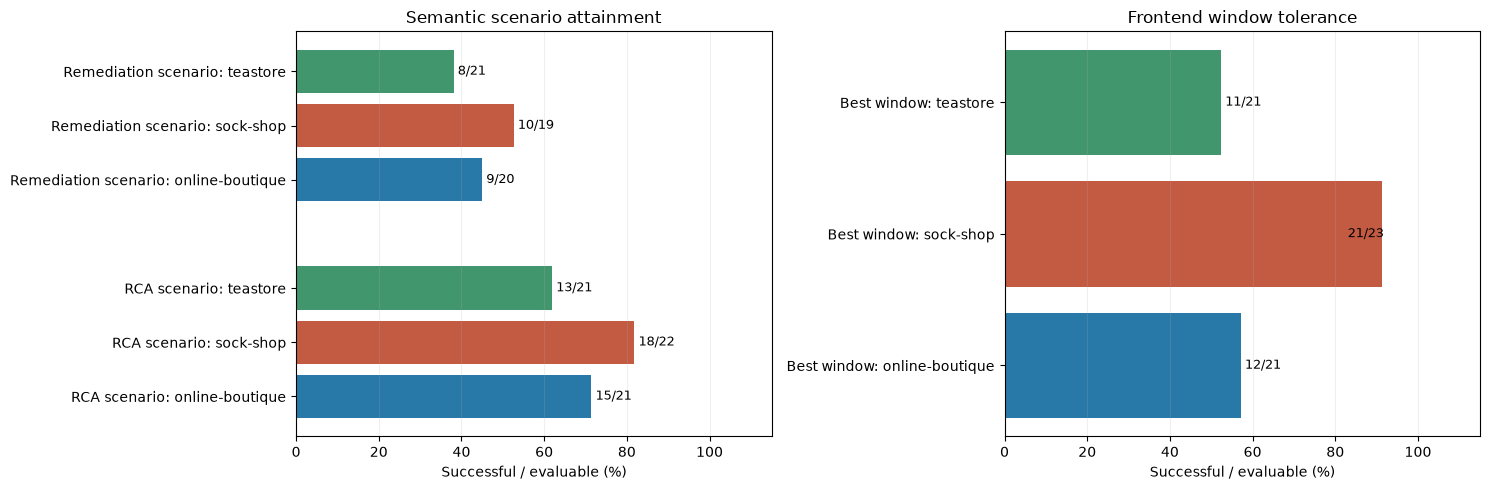

In [10]:
import eda.report_analysis as report_analysis
import eda.report as report_module
report_analysis = importlib.reload(report_analysis)
report_module = importlib.reload(report_module)
analysis_tables = report_analysis.numeric_summaries(all_runs, scenario_metrics, session_metrics, COMMON_CONFIG)
figure = report_module.comparison_chart(analysis_tables)
display(figure)
import matplotlib.pyplot as plt
plt.close(figure)


### Cohort


In [11]:
display(Markdown(markdown_table(analysis_tables["cohort"])))


| Application | Attempts | Selected scenarios/runs | Completed analyzed | Selected technical exclusions |
| --- | --- | --- | --- | --- |
| online-boutique | 23 | 21 | 21 | 0 |
| sock-shop | 23 | 23 | 23 | 0 |
| teastore | 23 | 23 | 21 | 2 |
| Total | 69 | 67 | 65 | 2 |

### Semantic success and window tolerance


In [12]:
display(Markdown(markdown_table(analysis_tables["semantic"])))


| Application | Metric | Success | Evaluable | Percent |
| --- | --- | --- | --- | --- |
| online-boutique | Successful RCA sessions (score &gt; 0.8) | 48 | 163 | 29.4479 |
| online-boutique | Scenarios/runs with successful RCA | 15 | 21 | 71.4286 |
| online-boutique | Successful REMEDIATION sessions (score &gt; 0.8) | 10 | 95 | 10.5263 |
| online-boutique | Scenarios/runs with successful REMEDIATION | 9 | 20 | 45.0000 |
| online-boutique | Holistic performance within tolerance (best window) | 12 | 21 | 57.1429 |
| sock-shop | Successful RCA sessions (score &gt; 0.8) | 41 | 169 | 24.2604 |
| sock-shop | Scenarios/runs with successful RCA | 18 | 22 | 81.8182 |
| sock-shop | Successful REMEDIATION sessions (score &gt; 0.8) | 19 | 103 | 18.4466 |
| sock-shop | Scenarios/runs with successful REMEDIATION | 10 | 19 | 52.6316 |
| sock-shop | Holistic performance within tolerance (best window) | 21 | 23 | 91.3043 |
| teastore | Successful RCA sessions (score &gt; 0.8) | 30 | 171 | 17.5439 |
| teastore | Scenarios/runs with successful RCA | 13 | 21 | 61.9048 |
| teastore | Successful REMEDIATION sessions (score &gt; 0.8) | 10 | 153 | 6.5359 |
| teastore | Scenarios/runs with successful REMEDIATION | 8 | 21 | 38.0952 |
| teastore | Holistic performance within tolerance (best window) | 11 | 21 | 52.3810 |
| Pooled total | Successful RCA sessions (score &gt; 0.8) | 119 | 503 | 23.6581 |
| Pooled total | Scenarios/runs with successful RCA | 46 | 64 | 71.8750 |
| Pooled total | Successful REMEDIATION sessions (score &gt; 0.8) | 39 | 351 | 11.1111 |
| Pooled total | Scenarios/runs with successful REMEDIATION | 27 | 60 | 45.0000 |
| Pooled total | Holistic performance within tolerance (best window) | 44 | 65 | 67.6923 |

### Score means


In [13]:
display(Markdown(markdown_table(analysis_tables["scores"])))


| Application | Output | Mean scenario maximum | Mean scenario mean | Pooled session mean |
| --- | --- | --- | --- | --- |
| online-boutique | rca | 0.8411 | 0.4815 | 0.4604 |
| online-boutique | remediation | 0.6094 | 0.3085 | 0.3353 |
| sock-shop | rca | 0.8415 | 0.4582 | 0.4564 |
| sock-shop | remediation | 0.7493 | 0.4173 | 0.3379 |
| teastore | rca | 0.7381 | 0.3636 | 0.3688 |
| teastore | remediation | 0.5887 | 0.2072 | 0.2053 |

### Sessions and Time to Maximum Score


In [14]:
display(Markdown(markdown_table(analysis_tables["sessions"])))


| Application | Output | Known sessions | Session counts known / runs | Scored | Sessions median | Sessions min | Sessions max | Time n | Time median (min) | Time Q1 | Time Q3 | Time min | Time max |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| online-boutique | rca | 163.0000 | 21/21 | 163 | 7.0000 | 4.0000 | 14.0000 | 21 | 13.3613 | 9.3115 | 18.7601 | 5.8011 | 39.2670 |
| online-boutique | remediation | 107.0000 | 21/21 | 95 | 4.0000 | 0.0000 | 9.0000 | 20 | 17.4002 | 13.6406 | 27.3866 | 5.1164 | 58.4307 |
| sock-shop | rca | 169.0000 | 23/23 | 169 | 8.0000 | 0.0000 | 15.0000 | 22 | 13.8615 | 7.2705 | 25.0828 | 4.4599 | 54.8804 |
| sock-shop | remediation | 110.0000 | 23/23 | 103 | 5.0000 | 0.0000 | 9.0000 | 19 | 15.3243 | 10.4915 | 33.0635 | 3.7573 | 59.0634 |
| teastore | rca | 171.0000 | 21/21 | 171 | 8.0000 | 4.0000 | 10.0000 | 21 | 21.7885 | 8.4487 | 34.6103 | 6.8483 | 53.4248 |
| teastore | remediation | 160.0000 | 21/21 | 153 | 8.0000 | 4.0000 | 9.0000 | 21 | 22.7014 | 10.4637 | 34.8523 | 3.2847 | 58.3791 |

### Window performance


In [15]:
display(Markdown(markdown_table(analysis_tables["performance"])))


| Application | Best tolerance | Median best P95 change (%) | Best P95 n |
| --- | --- | --- | --- |
| online-boutique | 12/21 | 1.0236 | 20 |
| sock-shop | 21/23 | -0.8200 | 22 |
| teastore | 11/21 | 2.5032 | 20 |
| Pooled total | 44/65 | -0.6199 | 62 |

### Semantic success versus best-window tolerance


In [16]:
display(Markdown(markdown_table(analysis_tables["joint"])))


| Output | Semantic success | Best passes | Best fails | Best unknown | Total |
| --- | --- | --- | --- | --- | --- |
| rca | True | 31 | 15 | 0 | 46 |
| rca | False | 12 | 6 | 0 | 18 |
| remediation | True | 19 | 8 | 0 | 27 |
| remediation | False | 20 | 13 | 0 | 33 |

### Fault-family outcomes


In [17]:
display(Markdown(markdown_table(analysis_tables["families"])))


| Family | Runs | RCA success | Remediation success | Best tolerance |
| --- | --- | --- | --- | --- |
| Node CPU | 3 | 2/3 | 1/3 | 3/3 |
| Node delay | 9 | 9/9 | 7/9 | 9/9 |
| Node packet loss | 9 | 4/9 | 2/9 | 2/9 |
| Node memory | 2 | 0/1 | 1/1 | 2/2 |
| Pod CPU headroom | 8 | 6/8 | 1/8 | 6/8 |
| Pod bandwidth | 5 | 0/5 | 0/2 | 4/5 |
| Pod capacity loss | 5 | 5/5 | 1/5 | 2/5 |
| Pod CPU | 15 | 13/15 | 9/14 | 8/15 |
| Pod memory | 9 | 7/9 | 5/9 | 8/9 |

### Fault families by application


In [18]:
display(Markdown(markdown_table(analysis_tables["family_app"])))


| Family | Application | Runs | RCA success | Remediation success | Best tolerance |
| --- | --- | --- | --- | --- | --- |
| Node CPU | online-boutique | 1 | 1/1 | 0/1 | 1/1 |
| Node CPU | sock-shop | 1 | 1/1 | 1/1 | 1/1 |
| Node CPU | teastore | 1 | 0/1 | 0/1 | 1/1 |
| Node delay | online-boutique | 3 | 3/3 | 2/3 | 3/3 |
| Node delay | sock-shop | 3 | 3/3 | 2/3 | 3/3 |
| Node delay | teastore | 3 | 3/3 | 3/3 | 3/3 |
| Node packet loss | online-boutique | 3 | 2/3 | 1/3 | 0/3 |
| Node packet loss | sock-shop | 3 | 2/3 | 1/3 | 2/3 |
| Node packet loss | teastore | 3 | 0/3 | 0/3 | 0/3 |
| Node memory | online-boutique | 1 | 0/1 | 1/1 | 1/1 |
| Node memory | sock-shop | 1 | — | — | 1/1 |
| Node memory | teastore | 0 | — | — | — |
| Pod CPU headroom | online-boutique | 3 | 2/3 | 0/3 | 2/3 |
| Pod CPU headroom | sock-shop | 3 | 3/3 | 1/3 | 3/3 |
| Pod CPU headroom | teastore | 2 | 1/2 | 0/2 | 1/2 |
| Pod bandwidth | online-boutique | 1 | 0/1 | — | 1/1 |
| Pod bandwidth | sock-shop | 2 | 0/2 | — | 2/2 |
| Pod bandwidth | teastore | 2 | 0/2 | 0/2 | 1/2 |
| Pod capacity loss | online-boutique | 1 | 1/1 | 0/1 | 0/1 |
| Pod capacity loss | sock-shop | 2 | 2/2 | 0/2 | 1/2 |
| Pod capacity loss | teastore | 2 | 2/2 | 1/2 | 1/2 |
| Pod CPU | online-boutique | 5 | 5/5 | 4/5 | 1/5 |
| Pod CPU | sock-shop | 5 | 4/5 | 3/4 | 5/5 |
| Pod CPU | teastore | 5 | 4/5 | 2/5 | 2/5 |
| Pod memory | online-boutique | 3 | 1/3 | 1/3 | 3/3 |
| Pod memory | sock-shop | 3 | 3/3 | 2/3 | 3/3 |
| Pod memory | teastore | 3 | 3/3 | 2/3 | 2/3 |

### Selected technical exclusions


In [19]:
display(Markdown(markdown_table(analysis_tables["exclusions"])))


| application | scenario | run | archive_status | grade_status |
| --- | --- | --- | --- | --- |
| teastore | teastore-node-memory-worker-3-one-hour | 20260923-161855-teastore-node-memory-worker-3-one-hour-09476bb4 | cleanup_failed | graded |
| teastore | teastore-pod-webui-cpu-headroom-all-one-hour | 20260924-034047-teastore-pod-webui-cpu-headroom-all-one-hour-844b969f | completed | graded |

## Optional details and export

Set `SHOW_DETAILS = True` for an audit table (application, run, field, value), including selection, status, timing, window coverage, and exclusion reasons. Full measurements remain in `scenario_metrics`, `session_metrics`, and `all_runs` regardless of display settings.

Set `EXPORT = True` to save the full CSVs and compact score Markdown to a new timestamped directory under `eda/exports/`. The configuration JSON records every application's input paths and workload/namespace settings.

In [20]:
SHOW_DETAILS = False
EXPORT = False

if SHOW_DETAILS:
    display_runs = all_runs.copy()
    for source_column in ("grade_path", "archive_path"):
        display_runs[source_column] = display_runs[source_column].map(
            lambda value: display_source_path(Path(value)) if value else None
        )
    detail_rows = display_runs.melt(id_vars=["application", "run"], var_name="Field", value_name="Value").rename(
        columns={"application": "Application", "run": "Run"}
    )
    display(Markdown(markdown_table(detail_rows)))
if EXPORT:
    output = GRADER_ROOT / "eda" / "exports" / pd.Timestamp.now(tz="UTC").strftime("report-%Y%m%d-%H%M%S-%f")
    output.mkdir(parents=True, exist_ok=False)
    for name, frame in {
        "scenario_metrics": scenario_metrics, "session_metrics": session_metrics,
        "aggregate_metrics": aggregate_metrics, "all_runs": all_runs,
    }.items():
        frame.to_csv(output / f"{name}.csv", index=False)
    import json
    (output / "configuration.json").write_text(json.dumps({
        application: {"grade_dir": report_module.display_source_path(paths["grade_dir"]),
                      "archive_dir": report_module.display_source_path(paths["archive_dir"]),
                      "config": vars(paths["config"])}
        for application, paths in APP_CONFIGS.items()
    }, indent=2), encoding="utf-8")
    (output / "scenario_scores.md").write_text(scenario_scores_markdown, encoding="utf-8")
    print(f"Exported to {output}")